# Executive Compensation — Feature-Rich Predictive Model v2

**Focus:** DAX companies (homogeneous large-cap universe, 2006–2021)  
**Features:** 60+ engineered features incl. lag comp, YoY financial growth, ratios, interactions  
**Targets:** `log_total_comp` (level) + `fixed_share`, `sti_share`, `lti_share` (structure)  
**Models:** Lasso, Ridge, Random Forest, LightGBM (with early stopping), XGBoost  
**Interpretation:** SHAP beeswarm + dependence plots, CEO vs non-CEO split


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import shap

shap.initjs()
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.3f}'.format)
DATA = Path('data')
SEED = 42
print('All imports OK')

All imports OK


## 1 · Load & Subset to DAX

In [2]:
raw = pd.read_csv(DATA / '2008-2024_longitudinal_orbis.csv', sep='|', low_memory=False)
print(f'Full dataset: {raw.shape[0]:,} rows × {raw.shape[1]} cols')

# DAX filter (academic period has index_listing; 2022-2024 DSW rows have NaN)
dax_mask = raw['index_listing'].isin(['DAX', 'DAX and MDAX'])
dax = raw[dax_mask].copy()
print(f'DAX subset:   {len(dax):,} rows, {dax["company_shortname"].nunique()} companies, '
      f'years {dax["year"].min()}–{dax["year"].max()}')
print()
print('Observations per year:')
print(dax.groupby('year').size().to_string())

Full dataset: 7,505 rows × 189 cols
DAX subset:   3,492 rows, 56 companies, years 2006–2021

Observations per year:
year
2006    219
2007    224
2008    232
2009    210
2010    200
2011    207
2012    226
2013    208
2014    210
2015    214
2016    224
2017    223
2018    205
2019    212
2020    212
2021    266


## 2 · Comprehensive Feature Engineering

60+ features across five groups:
1. **Executive** — role, demographics, tenure, experience
2. **Company size** — log-scaled ORBIS financials
3. **Financial ratios** — margins, leverage, efficiency
4. **Year-over-year growth** — revenue, profit, employment, assets
5. **Lag compensation** — executive's own pay last year, company avg last year


In [3]:
df = dax.copy()

# ── Dates ────────────────────────────────────────────────────────────────────
def parse_date(s):
    for fmt in ('%d%b%Y', '%Y-%m-%d', '%Y-%m-%dT%H:%M:%S', '%d/%m/%Y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    return pd.to_datetime(s, errors='coerce')

df['year_num'] = df['year'].astype(int)
year_end = pd.to_datetime(df['year_num'].astype(str) + '-12-31')

df['board_entry_dt'] = df['board_entry_date'].apply(parse_date)
df['board_exit_dt']  = df['board_exit_date'].apply(parse_date)
df['dob']            = df['date_of_birth'].apply(parse_date)

# ── Executive features ────────────────────────────────────────────────────────
df['is_ceo'] = (df['ceo_flag_eoy'] == 1).astype(int)
df['is_cfo'] = (df['cfo_flag_eoy'] == 1).astype(int)
df['is_other'] = ((df['is_ceo'] == 0) & (df['is_cfo'] == 0)).astype(int)

df['tenure_yrs']    = ((year_end - df['board_entry_dt']).dt.days / 365.25).clip(0, 40)
df['tenure_yrs_sq'] = df['tenure_yrs'] ** 2

df['age_at_ye'] = ((year_end - df['dob']).dt.days / 365.25).clip(28, 82)
df['age_sq']    = df['age_at_ye'] ** 2

df['female'] = pd.to_numeric(df['female'], errors='coerce')

df['has_title'] = df['exec_academic_title'].fillna('').str.strip().ne('').astype(int)

df['nationality_clean'] = df['nationality'].fillna('').str.lower().str.strip()
df['is_german'] = df['nationality_clean'].str.contains('german|deutsch').astype(int)

df['days_fraction'] = pd.to_numeric(df['days'], errors='coerce').clip(1, 366) / 365.25

df['n_executives'] = pd.to_numeric(df['n_executives'], errors='coerce')
df['log_n_exec']   = np.log1p(df['n_executives'])
df['n_exec_sq']    = df['n_executives'] ** 2

df['opting_out'] = pd.to_numeric(df['opting_out'], errors='coerce').fillna(0)

df['year_centered'] = df['year_num'] - 2013  # center on midpoint
df['year_sq']       = df['year_centered'] ** 2

print('Executive features done.')

Executive features done.


In [4]:
# ── ORBIS: parse all numeric ──────────────────────────────────────────────────
ORBIS_RAW = ['TURN','TOAS','EMPL','OPPL','STAF','PL','EBTA','SHFD','LTDB','CASH',
             'DEPR','INTE','RD','CF','COST','GROS','TAXA','ROE','ROA','ROCE',
             'PRMA','GRMA','GEAR','SOLR','CURR']
for c in ORBIS_RAW:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# ── Log-scale absolute financials (clip negatives to 0 before log) ───────────
for c in ['TURN','TOAS','EMPL','STAF','EBTA','OPPL','PL','SHFD','LTDB','CASH',
           'DEPR','INTE','RD','CF','COST','GROS']:
    df[f'log_{c}'] = np.log1p(df[c].clip(lower=0))

# ── Winsorise ratios ──────────────────────────────────────────────────────────
for c in ['ROE','ROA','ROCE','PRMA','GRMA','GEAR','SOLR','CURR']:
    p1, p99 = df[c].quantile([0.01, 0.99])
    df[c] = df[c].clip(p1, p99)

# ── Financial ratios ──────────────────────────────────────────────────────────
TURN_s = df['TURN'].replace(0, np.nan)
TOAS_s = df['TOAS'].replace(0, np.nan)
EMPL_s = df['EMPL'].replace(0, np.nan)
OPPL_s = df['OPPL'].replace(0, np.nan)

df['oppl_margin']       = (df['OPPL'] / TURN_s).clip(-2, 2)
df['ebta_margin']       = (df['EBTA'] / TURN_s).clip(-2, 2)
df['staf_per_empl']     = (df['STAF'] / EMPL_s).clip(0, 1000)   # €k per employee
df['labor_intensity']   = (df['STAF'] / TURN_s).clip(0, 2)
df['cash_ratio']        = (df['CASH'] / TOAS_s).clip(0, 1)
df['depr_rate']         = (df['DEPR'] / TOAS_s).clip(0, 0.5)
df['interest_coverage'] = (df['OPPL'] / df['INTE'].replace(0, np.nan)).clip(-20, 50)
df['rd_intensity']      = (df['RD'] / TURN_s).clip(0, 0.5)
df['debt_to_assets']    = (df['LTDB'] / TOAS_s).clip(0, 2)
df['debt_to_equity']    = (df['LTDB'] / df['SHFD'].replace(0, np.nan)).clip(-5, 20)
df['revenue_per_empl']  = (df['TURN'] / EMPL_s).clip(0, 5000)  # €k per employee

# Board-level salary context (avg salary at board level = company proxy)
for c in ['salary_bt','one_year_bonus_bt','total_equity_grants_bt','total_comp_bt']:
    df[c] = pd.to_numeric(df[c], errors='coerce').clip(lower=0)
    df[f'log_{c}'] = np.log1p(df[c])

print('ORBIS features done.')

ORBIS features done.


In [5]:
# ── Year-over-year financial growth rates (safe: lagged from same company) ────
# Build a company-year lookup of ORBIS financials for t-1
orbis_lag_cols = ['TURN', 'TOAS', 'EMPL', 'OPPL', 'PL', 'STAF', 'ROE', 'ROCE']
isin_year_orbis = (
    df[['isin','year_num'] + orbis_lag_cols]
    .drop_duplicates(['isin','year_num'])
    .sort_values(['isin','year_num'])
)
isin_year_orbis_lag = isin_year_orbis.copy()
isin_year_orbis_lag['year_num'] = isin_year_orbis_lag['year_num'] + 1
isin_year_orbis_lag.columns = ['isin','year_num'] + [f'{c}_lag1' for c in orbis_lag_cols]

df = df.merge(isin_year_orbis_lag, on=['isin','year_num'], how='left')

for c in orbis_lag_cols:
    lag_col = f'{c}_lag1'
    df[f'{c}_yoy'] = ((df[c] - df[lag_col]) / (df[lag_col].abs().replace(0, np.nan))).clip(-3, 5)

yoy_cols = [f'{c}_yoy' for c in orbis_lag_cols]
fill_yoy = df[yoy_cols].notna().mean()
print('YoY growth features:')
print(fill_yoy.round(2))

YoY growth features:
TURN_yoy   0.670
TOAS_yoy   0.660
EMPL_yoy   0.670
OPPL_yoy   0.660
PL_yoy     0.660
STAF_yoy   0.650
ROE_yoy    0.660
ROCE_yoy   0.660
dtype: float64


In [6]:
# ── Lag compensation features ─────────────────────────────────────────────────
# 1) Same executive, same company, year t-1
comp_cols_lag = ['total_comp','salary','one_year_bonus','total_equity_grants']
for c in comp_cols_lag:
    df[c] = pd.to_numeric(df[c], errors='coerce').clip(lower=0)

df_lag = (
    df[['company_person_id','isin','year_num'] + comp_cols_lag]
    .copy()
    .assign(year_num=lambda x: x['year_num'] + 1)
    .rename(columns={c: f'{c}_lag1' for c in comp_cols_lag})
)
df = df.merge(df_lag, on=['company_person_id','isin','year_num'], how='left')

df['log_own_comp_lag1']   = np.log1p(df['total_comp_lag1'].clip(lower=0))
df['log_own_salary_lag1'] = np.log1p(df['salary_lag1'].clip(lower=0))
df['comp_growth_yoy']     = ((df['total_comp'] - df['total_comp_lag1']) /
                              df['total_comp_lag1'].replace(0, np.nan)).clip(-2, 5)

# 2) Company average compensation, year t-1 (expanding-window, no leakage)
df_sorted = df.sort_values('year_num')
company_hist_avg = []
global_mean_log  = np.log1p(df['total_comp'].median())

for idx, row in df_sorted.iterrows():
    past = df_sorted.loc[
        (df_sorted['isin'] == row['isin']) & (df_sorted['year_num'] < row['year_num']),
        'total_comp'
    ]
    if len(past) > 0:
        company_hist_avg.append(np.log1p(past.median()))
    else:
        company_hist_avg.append(global_mean_log)

df_sorted['company_log_comp_hist'] = company_hist_avg
df = df_sorted  # keep sorted order

# 3) Lag structure shares
df['fixed_share_lag1'] = df['salary_lag1'] / (df['total_comp_lag1'].replace(0, np.nan))
df['lti_share_lag1']   = df['total_equity_grants_lag1'] / (df['total_comp_lag1'].replace(0, np.nan))
for c in ['fixed_share_lag1','lti_share_lag1']:
    df[c] = df[c].clip(0, 1)

lag_fill = df[['log_own_comp_lag1','log_own_salary_lag1','company_log_comp_hist',
               'fixed_share_lag1','lti_share_lag1']].notna().mean()
print('Lag comp feature fill rates:')
print(lag_fill.round(3))

Lag comp feature fill rates:
log_own_comp_lag1       0.785
log_own_salary_lag1     0.785
company_log_comp_hist   1.000
fixed_share_lag1        0.784
lti_share_lag1          0.745
dtype: float64


In [7]:
# ── Interaction features ──────────────────────────────────────────────────────
df['ceo_x_logTURN']   = df['is_ceo'] * df['log_TURN']
df['ceo_x_ROCE']      = df['is_ceo'] * df['ROCE']
df['ceo_x_tenure']    = df['is_ceo'] * df['tenure_yrs']
df['tenure_x_logTE']  = df['tenure_yrs'] * df['log_TOAS']
df['ceo_x_in_dax']    = df['is_ceo'] * (df['index_listing'] == 'DAX').astype(int)

print('Interaction features done.')

# ── Target variables ──────────────────────────────────────────────────────────
df['log_total_comp'] = np.log1p(df['total_comp'].clip(lower=0))

df['comp_sum'] = (
    df[['salary','one_year_bonus','total_equity_grants','other_annual_comp']]
    .apply(pd.to_numeric, errors='coerce').clip(lower=0)
    .sum(axis=1, min_count=1)
)
df['other_annual_comp'] = pd.to_numeric(df['other_annual_comp'], errors='coerce').clip(lower=0)
df['fixed_share'] = (df['salary']               / df['comp_sum'].replace(0, np.nan)).clip(0, 1)
df['sti_share']   = (df['one_year_bonus']        / df['comp_sum'].replace(0, np.nan)).clip(0, 1)
df['lti_share']   = (df['total_equity_grants']   / df['comp_sum'].replace(0, np.nan)).clip(0, 1)

print('Target variables done.')
print(f'Final DAX dataset: {df.shape}')

Interaction features done.
Target variables done.
Final DAX dataset: (3492, 273)


## 3 · Feature Matrix Definition

In [8]:
FEATURES = {
    'executive_role':   ['is_ceo', 'is_cfo', 'is_other', 'days_fraction'],
    'demographics':     ['female', 'is_german', 'has_title', 'tenure_yrs', 'tenure_yrs_sq', 'age_at_ye', 'age_sq'],
    'board_context':    ['log_n_exec', 'n_exec_sq', 'opting_out', 'year_centered', 'year_sq'],
    'company_size':     ['log_TURN', 'log_TOAS', 'log_EMPL', 'log_STAF', 'log_EBTA',
                         'log_OPPL', 'log_PL', 'log_SHFD', 'log_LTDB', 'log_CASH',
                         'log_DEPR', 'log_RD', 'log_CF', 'log_COST'],
    'ratios':           ['ROE', 'ROA', 'ROCE', 'PRMA', 'GRMA', 'CURR', 'SOLR', 'GEAR',
                         'oppl_margin', 'ebta_margin', 'staf_per_empl', 'labor_intensity',
                         'cash_ratio', 'depr_rate', 'interest_coverage', 'rd_intensity',
                         'debt_to_assets', 'debt_to_equity', 'revenue_per_empl'],
    'yoy_growth':       ['TURN_yoy', 'TOAS_yoy', 'EMPL_yoy', 'OPPL_yoy', 'PL_yoy',
                         'STAF_yoy', 'ROE_yoy', 'ROCE_yoy'],
    'lag_comp':         ['log_own_comp_lag1', 'log_own_salary_lag1', 'company_log_comp_hist',
                         'fixed_share_lag1', 'lti_share_lag1', 'comp_growth_yoy'],
    'board_total':      ['log_salary_bt', 'log_one_year_bonus_bt', 'log_total_equity_grants_bt'],
    'interactions':     ['ceo_x_logTURN', 'ceo_x_ROCE', 'ceo_x_tenure',
                         'tenure_x_logTE', 'ceo_x_in_dax'],
}

FEATURE_COLS = [f for group in FEATURES.values() for f in group]

# Remove features that don't exist in df
FEATURE_COLS = [f for f in FEATURE_COLS if f in df.columns]

print(f'Total features: {len(FEATURE_COLS)}')
for group, cols in FEATURES.items():
    avail = [c for c in cols if c in df.columns]
    print(f'  {group:20s}: {len(avail)} features')

# Check fill rates
fill = df[FEATURE_COLS].notna().mean().sort_values()
print(f'\nLowest fill rates (min {fill.min():.0%}):')
print(fill.head(12).round(3))

Total features: 71
  executive_role      : 4 features
  demographics        : 7 features
  board_context       : 5 features
  company_size        : 14 features
  ratios              : 19 features
  yoy_growth          : 8 features
  lag_comp            : 6 features
  board_total         : 3 features
  interactions        : 5 features

Lowest fill rates (min 62%):
rd_intensity   0.622
log_RD         0.623
STAF_yoy       0.651
TOAS_yoy       0.658
OPPL_yoy       0.658
ROCE_yoy       0.658
ROE_yoy        0.658
PL_yoy         0.658
EMPL_yoy       0.666
TURN_yoy       0.673
depr_rate      0.727
log_DEPR       0.727
dtype: float64


## 4 · Train/Test Split

Time-based: train 2006–2017 (≥2 years lag for encoding), test 2018–2021.

In [9]:
TARGET_AMOUNT    = 'log_total_comp'
TARGET_STRUCTURE = ['fixed_share', 'sti_share', 'lti_share']

# Require valid total_comp
mod = df[df[TARGET_AMOUNT].notna() & (df['total_comp'] > 10)].copy()
print(f'Valid rows: {len(mod):,}')

TRAIN_CUTOFF = 2017
train_mask = mod['year_num'] <= TRAIN_CUTOFF
test_mask  = mod['year_num'] >  TRAIN_CUTOFF

X_train = mod.loc[train_mask, FEATURE_COLS]
X_test  = mod.loc[test_mask,  FEATURE_COLS]
y_train = mod.loc[train_mask, TARGET_AMOUNT]
y_test  = mod.loc[test_mask,  TARGET_AMOUNT]

print(f'Train: {len(X_train):,} rows  years {mod.loc[train_mask,"year_num"].min()}–{mod.loc[train_mask,"year_num"].max()}')
print(f'Test:  {len(X_test):,} rows  years {mod.loc[test_mask,"year_num"].min()}–{mod.loc[test_mask,"year_num"].max()}')

# Also prep a validation set from 2016-2017 for early stopping
val_mask  = train_mask & (mod['year_num'] >= 2016)
pure_train = train_mask & (mod['year_num'] < 2016)
X_val  = mod.loc[val_mask, FEATURE_COLS]
y_val  = mod.loc[val_mask, TARGET_AMOUNT]
X_ptr  = mod.loc[pure_train, FEATURE_COLS]
y_ptr  = mod.loc[pure_train, TARGET_AMOUNT]
print(f'Inner val: {val_mask.sum()} rows, inner train: {pure_train.sum()} rows')

Valid rows: 3,483
Train: 2,588 rows  years 2006–2017
Test:  895 rows  years 2018–2021
Inner val: 446 rows, inner train: 2142 rows


## 5 · Models — Compensation Level

In [10]:
results = []

def evaluate(name, pipe_or_model, Xtr, ytr, Xte, yte, fit_kwargs=None):
    if fit_kwargs:
        pipe_or_model.fit(Xtr, ytr, **fit_kwargs)
    else:
        pipe_or_model.fit(Xtr, ytr)
    pred  = pipe_or_model.predict(Xte)
    r2    = r2_score(yte, pred)
    mae_k = mean_absolute_error(np.expm1(yte), np.expm1(pred))
    rmse  = np.sqrt(mean_squared_error(yte, pred))
    print(f'{name:25s}  R²={r2:.3f}  MAE={mae_k:.0f}k  RMSE_log={rmse:.3f}')
    results.append({'model': name, 'R²': r2, 'MAE_€k': mae_k, 'RMSE_log': rmse,
                    '_model': pipe_or_model, '_pred': pred})
    return pipe_or_model, pred

imp = SimpleImputer(strategy='median')
imp.fit(X_train)
Xtr_imp  = pd.DataFrame(imp.transform(X_train), columns=FEATURE_COLS)
Xte_imp  = pd.DataFrame(imp.transform(X_test),  columns=FEATURE_COLS)
Xval_imp = pd.DataFrame(imp.transform(X_val),   columns=FEATURE_COLS)
Xptr_imp = pd.DataFrame(imp.transform(X_ptr),   columns=FEATURE_COLS)

scaler = StandardScaler().fit(Xtr_imp)
Xtr_sc = scaler.transform(Xtr_imp)
Xte_sc = scaler.transform(Xte_imp)

print('Data ready for modelling.')

Data ready for modelling.


In [11]:

# ── Linear models ─────────────────────────────────────────────────────────────
from sklearn.linear_model import RidgeCV, LassoCV

# Ridge with CV alpha selection
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]).fit(Xtr_sc, y_train)
print(f'Ridge best alpha: {ridge.alpha_}')
evaluate('Ridge (CV-alpha)', ridge, Xtr_sc, y_train, Xte_sc, y_test)

# Lasso with CV alpha selection
lasso = LassoCV(cv=5, max_iter=5000).fit(Xtr_sc, y_train)
print(f'Lasso best alpha: {lasso.alpha_:.5f}')
evaluate('Lasso (CV-alpha)', lasso, Xtr_sc, y_train, Xte_sc, y_test)

# Lasso feature selection
nonzero = pd.Series(lasso.coef_, index=FEATURE_COLS)
nonzero = nonzero[nonzero != 0].sort_values(key=abs, ascending=False)
print(f'\nLasso selected {len(nonzero)} / {len(FEATURE_COLS)} features:')
print(nonzero.round(4).to_string())

Ridge best alpha: 100.0
Ridge (CV-alpha)           R²=0.697  MAE=667k  RMSE_log=0.412


Lasso best alpha: 0.01367


Lasso (CV-alpha)           R²=0.723  MAE=577k  RMSE_log=0.394

Lasso selected 31 / 71 features:
days_fraction                 0.397
log_own_comp_lag1             0.283
comp_growth_yoy               0.234
log_salary_bt                 0.088
company_log_comp_hist         0.062
log_total_equity_grants_bt    0.056
log_one_year_bonus_bt         0.045
tenure_yrs                    0.034
ceo_x_in_dax                  0.032
log_n_exec                   -0.031
age_at_ye                     0.028
log_CASH                      0.027
ceo_x_logTURN                 0.026
is_ceo                        0.024
log_own_salary_lag1           0.018
TURN_yoy                      0.017
is_german                    -0.015
year_centered                 0.015
rd_intensity                  0.015
ROCE                          0.015
OPPL_yoy                      0.011
fixed_share_lag1             -0.011
ceo_x_ROCE                    0.011
log_TOAS                      0.011
year_sq                      -0.010
log_

In [12]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=400, max_depth=None, min_samples_leaf=3,
    max_features='sqrt', n_jobs=-1, random_state=SEED
)
evaluate('RandomForest', rf, Xtr_imp, y_train, Xte_imp, y_test)

# Native feature importance
rf_fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print('\nTop 15 RF feature importances:')
print(rf_fi.head(15).round(4))

RandomForest               R²=0.741  MAE=595k  RMSE_log=0.381

Top 15 RF feature importances:
days_fraction                0.164
comp_growth_yoy              0.125
log_own_comp_lag1            0.079
tenure_yrs_sq                0.050
tenure_yrs                   0.048
log_total_equity_grants_bt   0.045
company_log_comp_hist        0.044
log_own_salary_lag1          0.035
log_one_year_bonus_bt        0.030
ceo_x_in_dax                 0.026
log_salary_bt                0.025
tenure_x_logTE               0.023
ceo_x_tenure                 0.018
fixed_share_lag1             0.016
is_ceo                       0.016
dtype: float64


In [13]:
# ── LightGBM with early stopping ──────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=8,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.05, reg_lambda=0.5, min_child_samples=10,
    n_jobs=-1, random_state=SEED, verbose=-1
)
lgb_model.fit(
    Xptr_imp, y_ptr,
    eval_set=[(Xval_imp, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
print(f'LightGBM best iteration: {lgb_model.best_iteration_}')
evaluate('LightGBM (early-stop)', lgb_model, Xtr_imp, y_train, Xte_imp, y_test)

LightGBM best iteration: 739


LightGBM (early-stop)      R²=0.822  MAE=360k  RMSE_log=0.316


(LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
               min_child_samples=10, n_estimators=2000, n_jobs=-1, num_leaves=63,
               random_state=42, reg_alpha=0.05, reg_lambda=0.5, subsample=0.8,
               verbose=-1),
 array([6.2527661 , 7.73059942, 7.94081539, 6.57750478, 6.57372985,
        6.9911933 , 8.09856137, 8.49374066, 8.14715197, 8.37110616,
        7.35423293, 7.84764655, 8.33808891, 8.23260101, 8.50806124,
        8.10594982, 8.45869071, 7.99439934, 8.0680788 , 8.06977702,
        8.03851823, 8.0186062 , 8.18250988, 7.95144134, 6.12395211,
        7.1983199 , 8.09853272, 8.11176506, 7.95815592, 7.76435425,
        7.60530158, 7.71861215, 7.44903898, 7.83964106, 7.93621622,
        8.6835538 , 8.82257342, 8.39685233, 8.14673918, 7.8767105 ,
        8.93885297, 8.20479514, 8.05082368, 7.83086121, 8.75292576,
        8.2478085 , 6.92512384, 7.97531975, 8.71618593, 8.03169135,
        6.13039316, 7.97438921, 8.16750246, 8.86342936, 8.193

In [14]:

# ── XGBoost — use LightGBM's optimal iteration as guidance ────────────────────
n_est_xgb = max(100, lgb_model.best_iteration_ or 300)
xgb_model = xgb.XGBRegressor(
    n_estimators=n_est_xgb, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.05, reg_lambda=0.5, min_child_weight=5,
    n_jobs=-1, random_state=SEED, verbosity=0,
)
xgb_model.fit(Xtr_imp.values, y_train.values)
print(f'XGBoost n_estimators={n_est_xgb}')
evaluate('XGBoost', xgb_model, Xtr_imp.values, y_train, Xte_imp.values, y_test)

XGBoost n_estimators=300


XGBoost                    R²=0.824  MAE=375k  RMSE_log=0.314


(XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...),
 array([6.166233 , 7.735811 , 7.9047885, 6.6068826, 6.600265 , 7.0677314,
        8.252426 , 8.473228 , 8.149928 , 8.414979 , 7.425597 , 7.842486 ,
        8.271797 , 8.23995  , 8.547122 , 7.9805655, 8.461544 , 7.98902  ,
        8.001653 , 7.946456

=== Compensation Level — Model Comparison (DAX holdout 2018–2021) ===
                model    R²  MAE_€k  RMSE_log
              XGBoost 0.824 374.713     0.314
LightGBM (early-stop) 0.822 359.819     0.316
         RandomForest 0.741 595.391     0.381
     Lasso (CV-alpha) 0.723 577.308     0.394
     Ridge (CV-alpha) 0.697 667.455     0.412


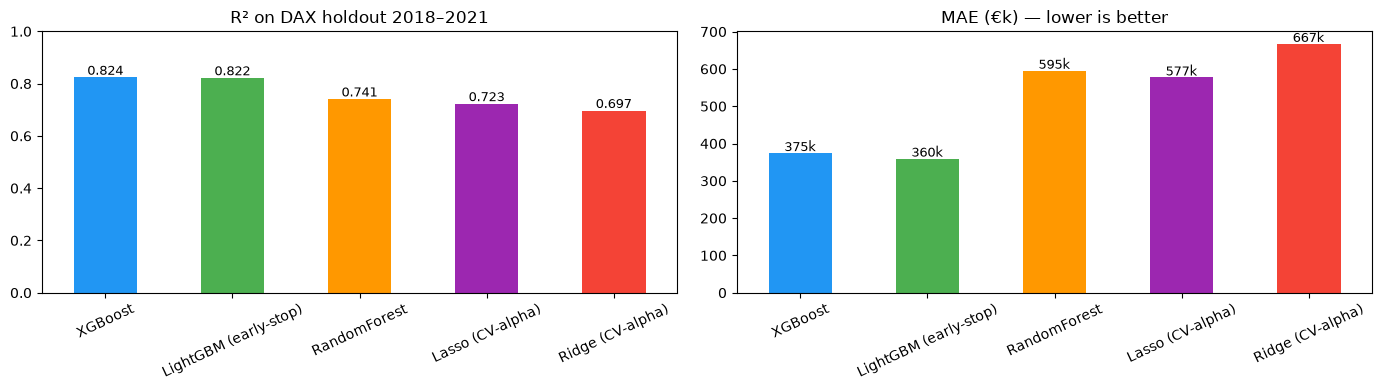

In [15]:
# ── Comparison ────────────────────────────────────────────────────────────────
perf = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
perf = perf.sort_values('R²', ascending=False).reset_index(drop=True)

print('=== Compensation Level — Model Comparison (DAX holdout 2018–2021) ===')
print(perf.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors_bar = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'][:len(perf)]
perf.plot(x='model', y='R²', kind='bar', ax=axes[0], color=colors_bar, legend=False)
axes[0].set_title('R² on DAX holdout 2018–2021')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylim(0, 1)
for i, v in enumerate(perf['R²']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

perf.plot(x='model', y='MAE_€k', kind='bar', ax=axes[1], color=colors_bar, legend=False)
axes[1].set_title('MAE (€k) — lower is better')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(perf['MAE_€k']):
    axes[1].text(i, v + 5, f'{v:.0f}k', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Best model: XGBoost  R²=0.824


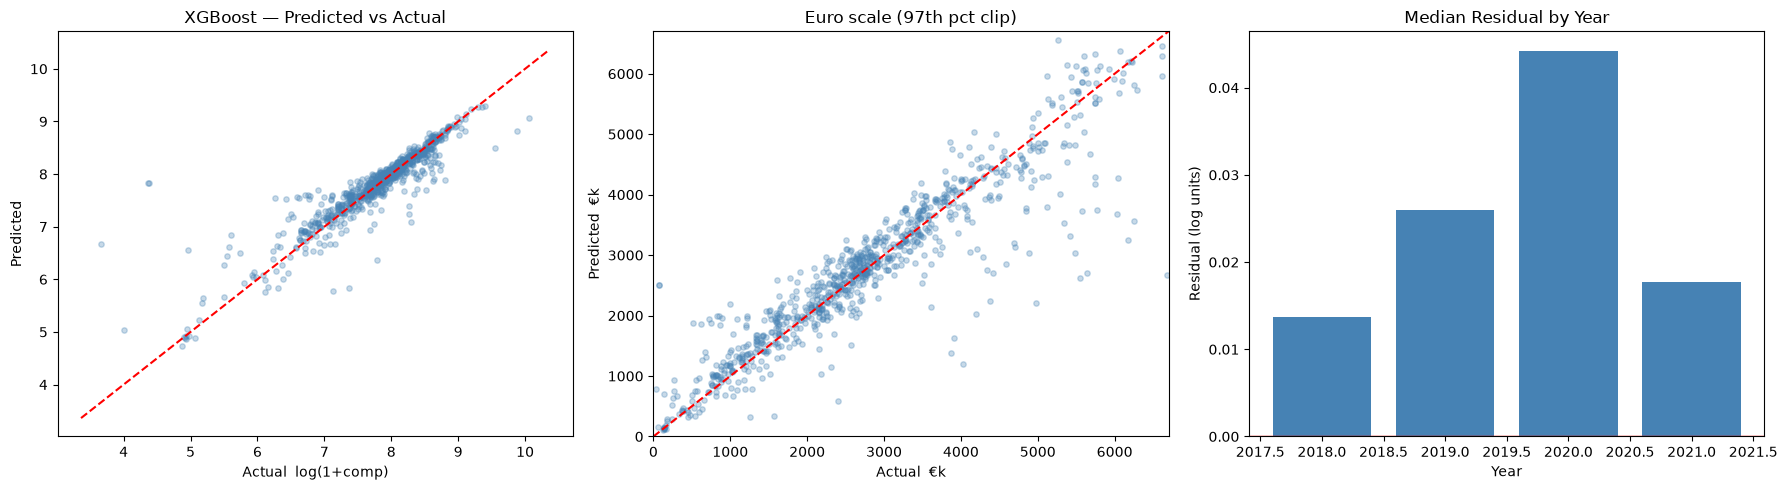

In [16]:
# Predicted vs actual for best model
best = max(results, key=lambda r: r['R²'])
print(f'Best model: {best["model"]}  R²={best["R²"]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Log scale scatter
lim = (y_test.min() - 0.3, y_test.max() + 0.3)
axes[0].scatter(y_test, best['_pred'], alpha=0.3, s=15, color='steelblue')
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlabel('Actual  log(1+comp)'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best["model"]} — Predicted vs Actual')

# Actual euro scale
ax1 = axes[1]
y_act_k = np.expm1(y_test)
y_pre_k = np.expm1(best['_pred'])
lim_k = (0, np.percentile(y_act_k, 97))
ax1.scatter(y_act_k, y_pre_k, alpha=0.3, s=15, color='steelblue')
ax1.plot(lim_k, lim_k, 'r--', lw=1.5)
ax1.set_xlim(lim_k); ax1.set_ylim(lim_k)
ax1.set_xlabel('Actual  €k'); ax1.set_ylabel('Predicted  €k')
ax1.set_title('Euro scale (97th pct clip)')

# Residuals by year
resid = pd.Series(best['_pred'] - y_test.values, index=y_test.index)
mod.loc[test_mask, 'resid'] = resid
yr_res = mod.loc[test_mask].groupby('year_num')['resid'].median()
axes[2].bar(yr_res.index, yr_res.values, color='steelblue')
axes[2].axhline(0, color='red', lw=1)
axes[2].set_title('Median Residual by Year')
axes[2].set_xlabel('Year'); axes[2].set_ylabel('Residual (log units)')

plt.tight_layout()
plt.show()

## 6 · SHAP Feature Importance

In [17]:
# Use LightGBM (fastest SHAP)
# Re-train on full train set (not inner train)
lgb_full = lgb.LGBMRegressor(
    n_estimators=lgb_model.best_iteration_ or 300,
    learning_rate=0.03, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.05, reg_lambda=0.5, min_child_samples=10,
    n_jobs=-1, random_state=SEED, verbose=-1
).fit(Xtr_imp, y_train)

explainer   = shap.TreeExplainer(lgb_full)
shap_values = explainer.shap_values(Xte_imp)

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': mean_shap})\
              .sort_values('mean_abs_shap', ascending=False)

print('Top 20 features by mean |SHAP|:')
print(shap_df.head(20).to_string(index=False))

Top 20 features by mean |SHAP|:
                   feature  mean_abs_shap
         log_own_comp_lag1          0.220
             days_fraction          0.212
           comp_growth_yoy          0.139
log_total_equity_grants_bt          0.081
     company_log_comp_hist          0.044
     log_one_year_bonus_bt          0.038
       log_own_salary_lag1          0.025
                tenure_yrs          0.025
             log_salary_bt          0.023
                    is_ceo          0.018
             year_centered          0.014
             tenure_yrs_sq          0.013
                log_n_exec          0.011
              ceo_x_in_dax          0.010
                    log_PL          0.008
            debt_to_assets          0.007
          fixed_share_lag1          0.006
                 age_at_ye          0.006
                  log_CASH          0.006
                 is_german          0.005


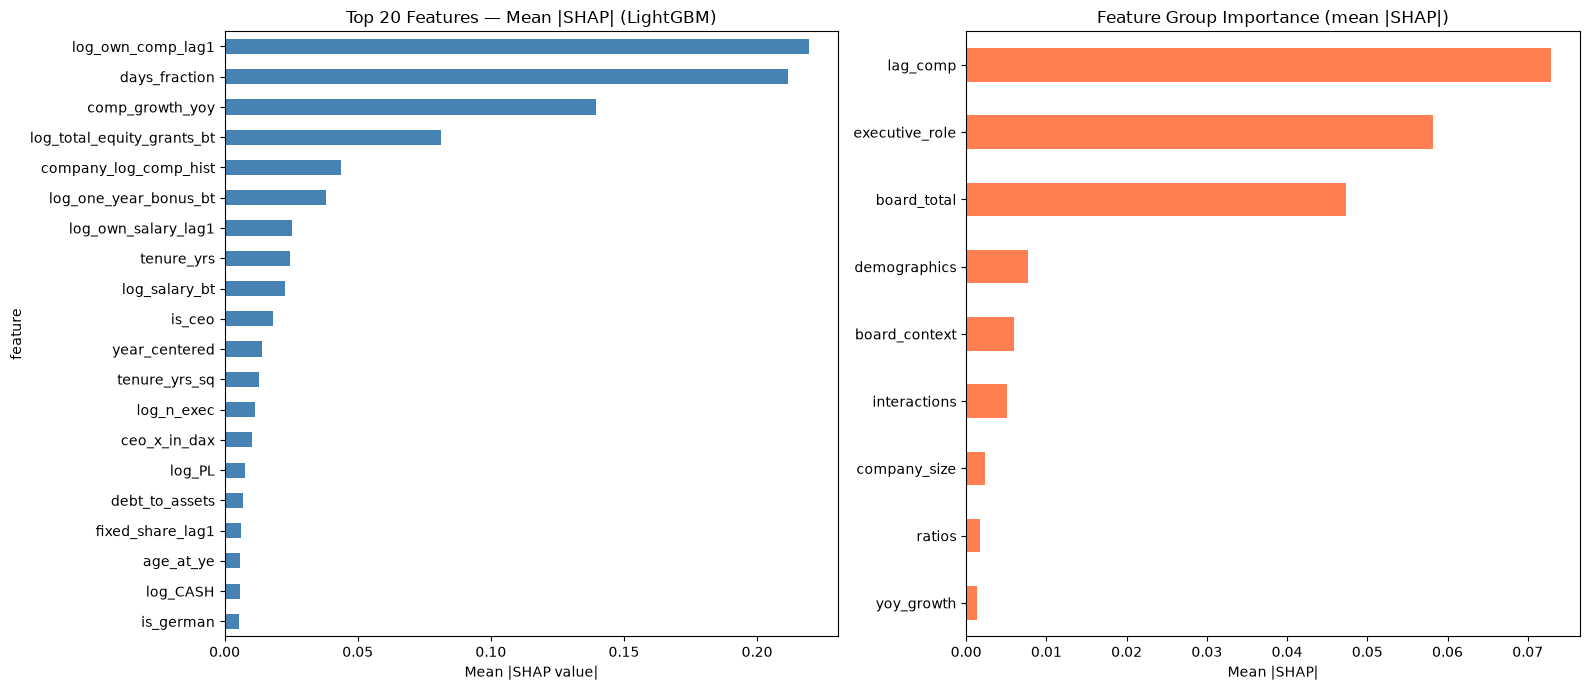

In [18]:
# Grouped SHAP importance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Individual features
shap_df.head(20).sort_values('mean_abs_shap').plot(
    x='feature', y='mean_abs_shap', kind='barh',
    ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Top 20 Features — Mean |SHAP| (LightGBM)')
axes[0].set_xlabel('Mean |SHAP value|')

# Group-level importance
group_shap = {}
for group, cols in FEATURES.items():
    avail = [c for c in cols if c in FEATURE_COLS]
    if avail:
        idx = [FEATURE_COLS.index(c) for c in avail]
        group_shap[group] = np.abs(shap_values[:, idx]).mean()

grp_df = pd.Series(group_shap).sort_values()
grp_df.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Feature Group Importance (mean |SHAP|)')
axes[1].set_xlabel('Mean |SHAP|')

plt.tight_layout()
plt.show()

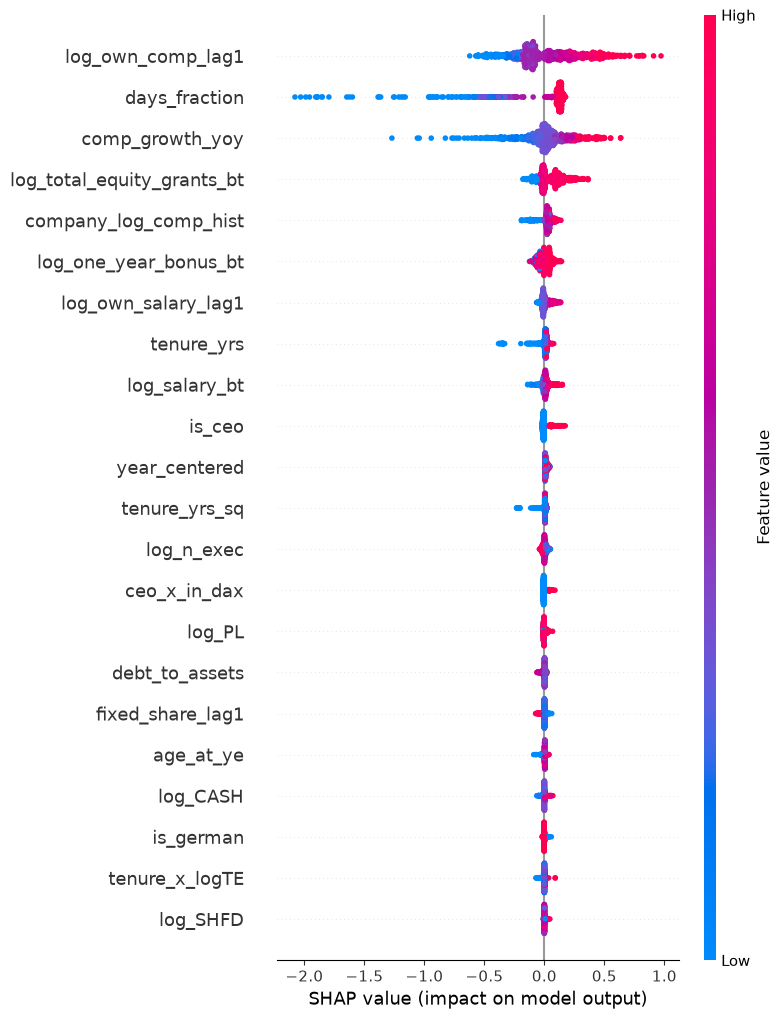

In [19]:
shap.summary_plot(shap_values, Xte_imp, feature_names=FEATURE_COLS, max_display=22, show=True)

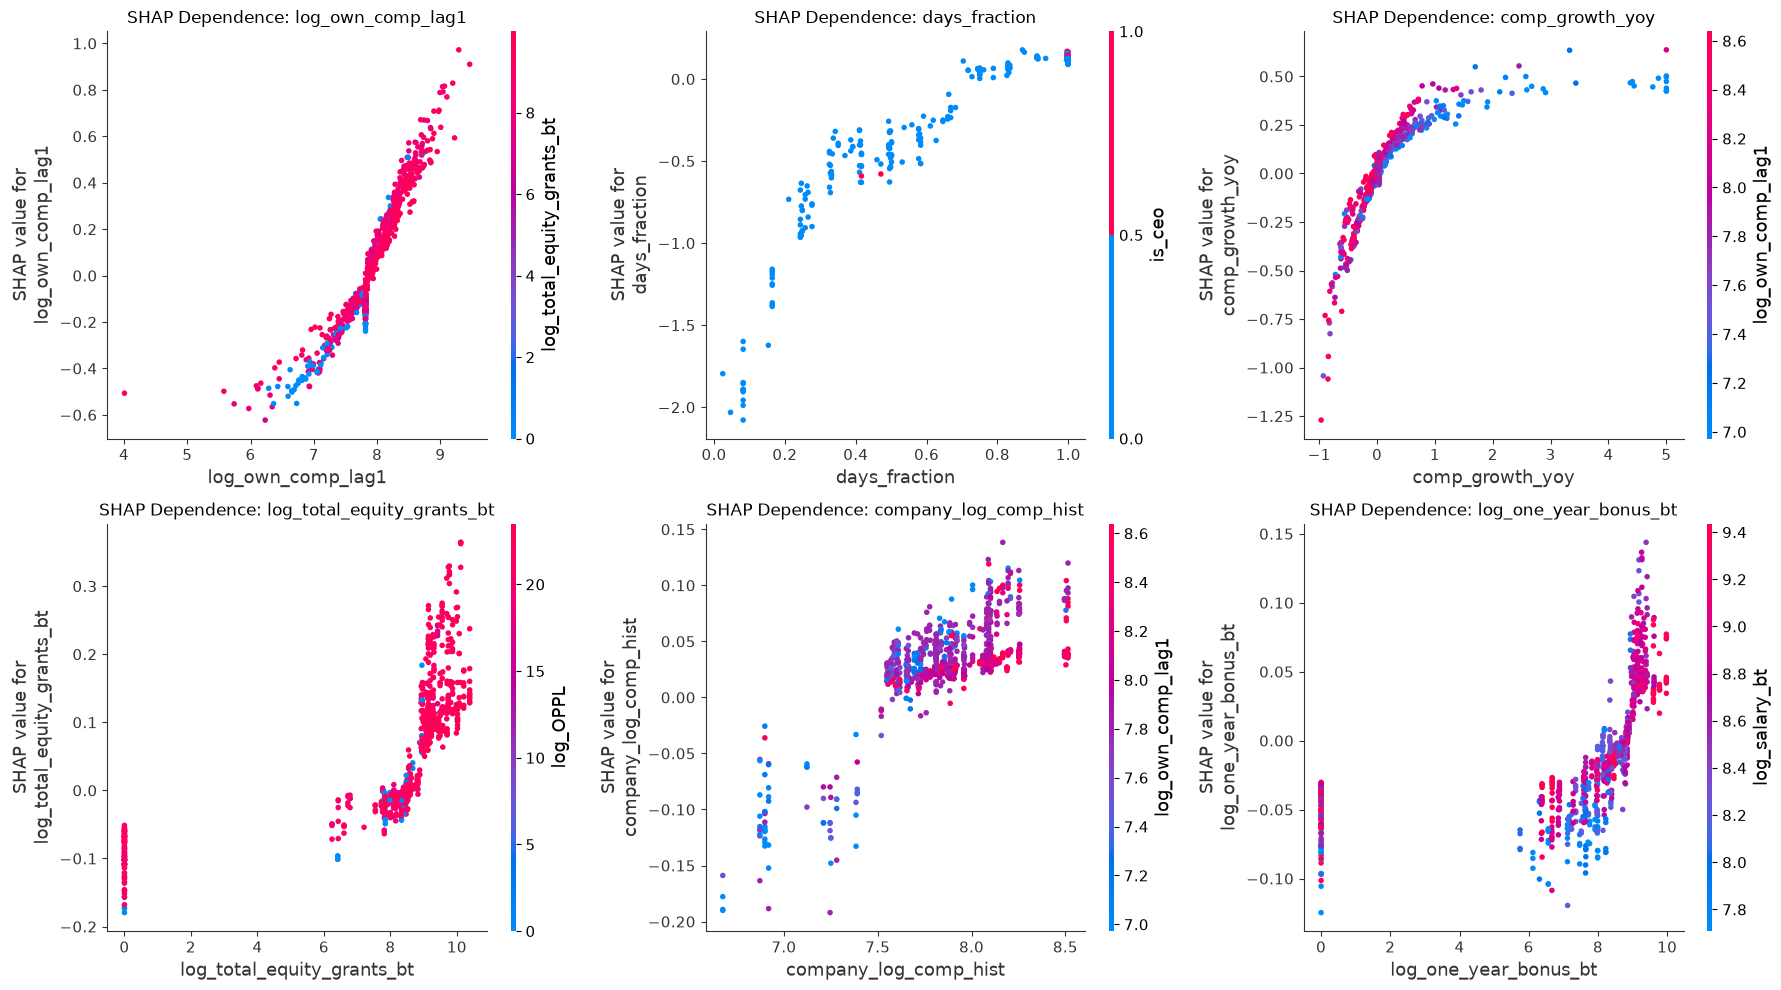

In [20]:
# Dependence plots for top 6 features
top6 = shap_df.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(top6):
    shap.dependence_plot(feat, shap_values, Xte_imp, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feat}')
plt.tight_layout()
plt.show()

## 7 · Lasso Coefficients — Linear Effects

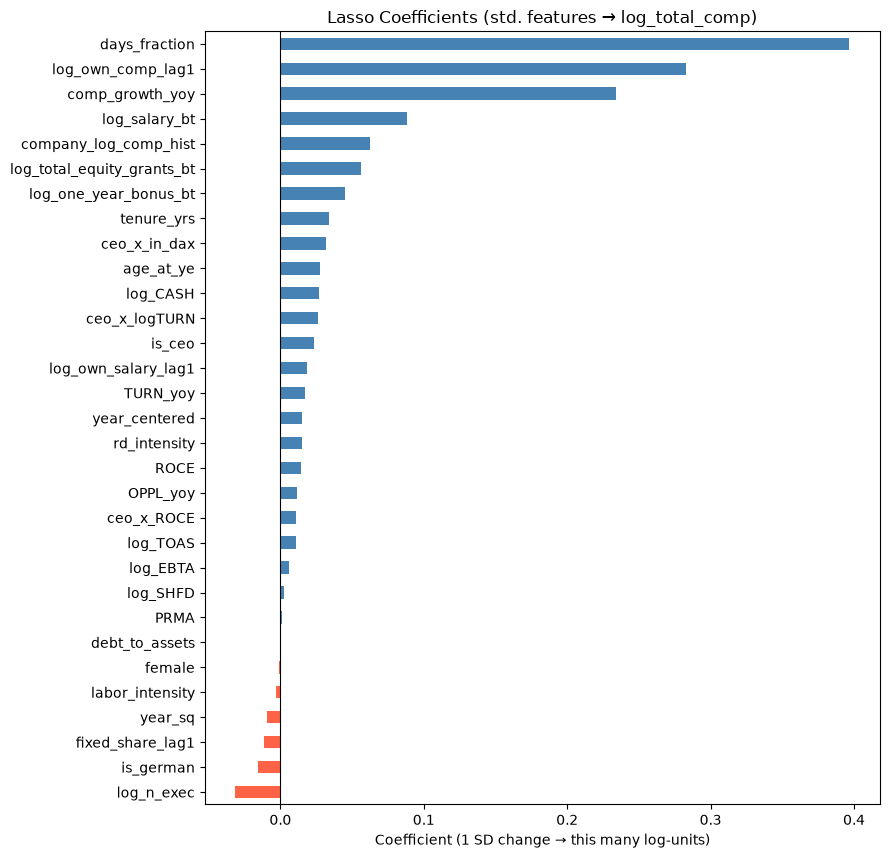

Lasso non-zero coefficients:
log_n_exec                   -0.031
is_german                    -0.015
fixed_share_lag1             -0.011
year_sq                      -0.010
labor_intensity              -0.003
female                       -0.001
debt_to_assets               -0.000
PRMA                          0.001
log_SHFD                      0.002
log_EBTA                      0.006
log_TOAS                      0.011
ceo_x_ROCE                    0.011
OPPL_yoy                      0.011
ROCE                          0.015
rd_intensity                  0.015
year_centered                 0.015
TURN_yoy                      0.017
log_own_salary_lag1           0.018
is_ceo                        0.024
ceo_x_logTURN                 0.026
log_CASH                      0.027
age_at_ye                     0.028
ceo_x_in_dax                  0.032
tenure_yrs                    0.034
log_one_year_bonus_bt         0.045
log_total_equity_grants_bt    0.056
company_log_comp_hist         0.062

In [21]:
coef = pd.Series(lasso.coef_, index=FEATURE_COLS)
coef_nonzero = coef[coef != 0].sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_nonzero) * 0.28)))
colors_l = ['tomato' if v < 0 else 'steelblue' for v in coef_nonzero]
coef_nonzero.plot(kind='barh', ax=ax, color=colors_l)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Lasso Coefficients (std. features → log_total_comp)')
ax.set_xlabel('Coefficient (1 SD change → this many log-units)')
plt.tight_layout()
plt.show()

print('Lasso non-zero coefficients:')
print(coef_nonzero.round(4).to_string())

## 8 · Expanding-Window Cross-Validation (DAX)

=== Expanding-Window CV — LightGBM on DAX ===
 year  n_train  n_test    R²  MAE_€k
 2012     1287     223 0.840 388.015
 2013     1510     208 0.955 255.708
 2014     1718     210 0.900 256.486
 2015     1928     214 0.813 316.133
 2016     2142     224 0.919 269.998
 2017     2366     222 0.872 375.138
 2018     2588     205 0.828 377.261
 2019     2793     212 0.925 238.263
 2020     3005     212 0.866 286.687
 2021     3217     266 0.758 429.162

Mean R²: 0.868  ±0.060
Mean MAE: 319k  ±68k


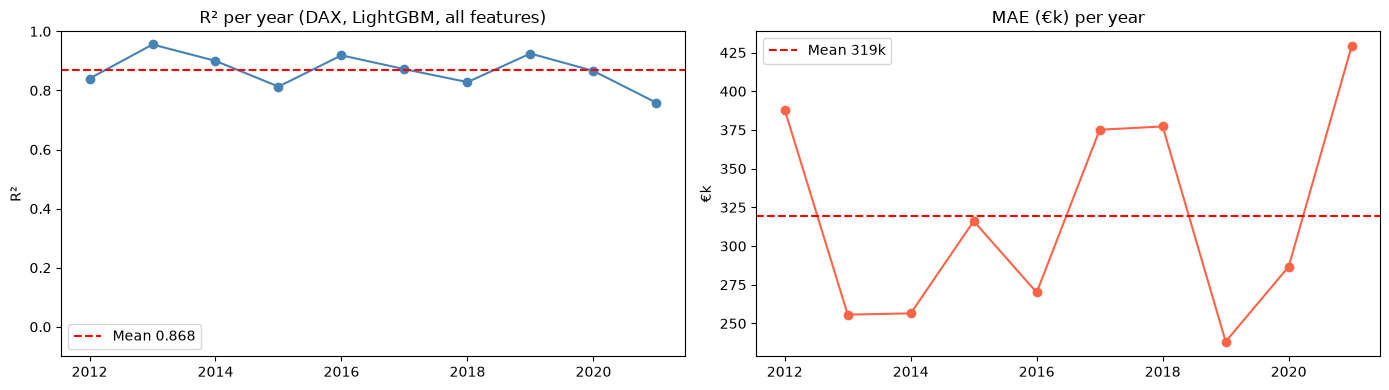

In [22]:
cv_rows = []
for ty in range(2012, 2022):
    tr = mod['year_num'] < ty
    te = mod['year_num'] == ty
    if tr.sum() < 80 or te.sum() < 15:
        continue

    Xtr_cv = mod.loc[tr, FEATURE_COLS]
    Xte_cv = mod.loc[te, FEATURE_COLS]
    ytr_cv = mod.loc[tr, TARGET_AMOUNT]
    yte_cv = mod.loc[te, TARGET_AMOUNT]

    imp_cv = SimpleImputer(strategy='median').fit(Xtr_cv)
    Xtr_f  = imp_cv.transform(Xtr_cv)
    Xte_f  = imp_cv.transform(Xte_cv)

    mdl_cv = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=8,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=SEED, verbose=-1
    ).fit(Xtr_f, ytr_cv)

    pred_cv = mdl_cv.predict(Xte_f)
    r2  = r2_score(yte_cv, pred_cv)
    mae = mean_absolute_error(np.expm1(yte_cv), np.expm1(pred_cv))
    cv_rows.append({'year': ty, 'n_train': tr.sum(), 'n_test': te.sum(),
                    'R²': r2, 'MAE_€k': mae})

cv_df = pd.DataFrame(cv_rows)
print('=== Expanding-Window CV — LightGBM on DAX ===')
print(cv_df.to_string(index=False))
print(f'\nMean R²: {cv_df["R²"].mean():.3f}  ±{cv_df["R²"].std():.3f}')
print(f'Mean MAE: {cv_df["MAE_€k"].mean():.0f}k  ±{cv_df["MAE_€k"].std():.0f}k')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cv_df['year'], cv_df['R²'], marker='o', color='steelblue')
axes[0].axhline(cv_df['R²'].mean(), color='red', linestyle='--',
                label=f'Mean {cv_df["R²"].mean():.3f}')
axes[0].set_title('R² per year (DAX, LightGBM, all features)')
axes[0].set_ylabel('R²'); axes[0].set_ylim(-0.1, 1); axes[0].legend()

axes[1].plot(cv_df['year'], cv_df['MAE_€k'], marker='o', color='tomato')
axes[1].axhline(cv_df['MAE_€k'].mean(), color='red', linestyle='--',
                label=f'Mean {cv_df["MAE_€k"].mean():.0f}k')
axes[1].set_title('MAE (€k) per year'); axes[1].set_ylabel('€k'); axes[1].legend()

plt.tight_layout()
plt.show()

## 9 · CEO vs Non-CEO — Separate Models

In [23]:
def split_model(label, submask, feature_cols=FEATURE_COLS, target=TARGET_AMOUNT):
    sub     = mod[submask].copy()
    tr_sub  = sub['year_num'] <= TRAIN_CUTOFF
    te_sub  = sub['year_num'] >  TRAIN_CUTOFF

    if tr_sub.sum() < 50 or te_sub.sum() < 10:
        print(f'{label}: skipped (train={tr_sub.sum()}, test={te_sub.sum()})')
        return None

    Xtr_s = sub.loc[tr_sub, feature_cols]
    Xte_s = sub.loc[te_sub, feature_cols]
    ytr_s = sub.loc[tr_sub, target]
    yte_s = sub.loc[te_sub, target]

    imp_s = SimpleImputer(strategy='median').fit(Xtr_s)
    Xtr_f = imp_s.transform(Xtr_s)
    Xte_f = imp_s.transform(Xte_s)

    mdl = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=7, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=SEED, verbose=-1
    ).fit(Xtr_f, ytr_s)

    pred   = mdl.predict(Xte_f)
    r2     = r2_score(yte_s, pred)
    mae_k  = mean_absolute_error(np.expm1(yte_s), np.expm1(pred))

    # SHAP
    Xte_imp_s = pd.DataFrame(Xte_f, columns=feature_cols)
    expl      = shap.TreeExplainer(mdl)
    sv        = expl.shap_values(Xte_imp_s)
    imp_df    = pd.DataFrame({'feature': feature_cols,
                               'mean_abs_shap': np.abs(sv).mean(axis=0)})\
                  .sort_values('mean_abs_shap', ascending=False)

    print(f'{label:20s}  train={tr_sub.sum():>4}  test={te_sub.sum():>3}  '
          f'R²={r2:.3f}  MAE={mae_k:.0f}k')
    return {'label': label, 'r2': r2, 'mae_k': mae_k,
            'sv': sv, 'Xte': Xte_imp_s, 'imp_df': imp_df}

print('--- CEO / CFO / Other split ---')
ceo_r  = split_model('CEO',      mod['is_ceo'] == 1)
nceo_r = split_model('Non-CEO',  mod['is_ceo'] == 0)
cfo_r  = split_model('CFO only', (mod['is_cfo'] == 1) & (mod['is_ceo'] == 0))

--- CEO / CFO / Other split ---


CEO                   train= 378  test=135  R²=0.483  MAE=930k


Non-CEO               train=2210  test=760  R²=0.841  MAE=326k


CFO only              train= 356  test=130  R²=0.744  MAE=435k


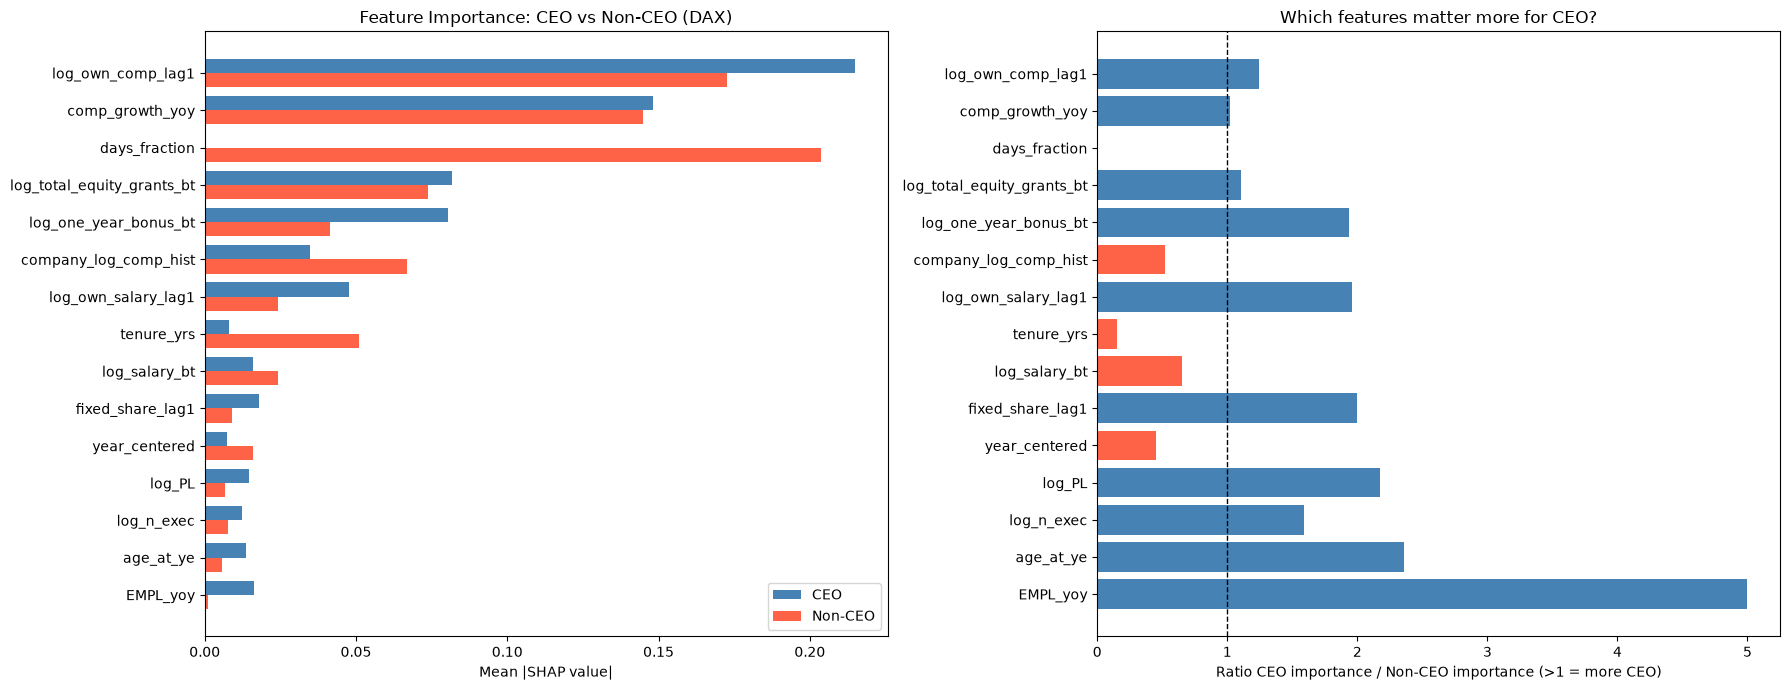

In [24]:
if ceo_r and nceo_r:
    top_n = 15
    ceo_imp  = ceo_r['imp_df'].set_index('feature')['mean_abs_shap'].rename('CEO')
    nceo_imp = nceo_r['imp_df'].set_index('feature')['mean_abs_shap'].rename('Non-CEO')
    cmp = pd.concat([ceo_imp, nceo_imp], axis=1).fillna(0)
    cmp['total'] = cmp.sum(axis=1)
    cmp = cmp.sort_values('total', ascending=False).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # side-by-side bar
    x = np.arange(len(cmp))
    w = 0.38
    axes[0].barh(x - w/2, cmp['CEO'],     w, label='CEO',     color='steelblue')
    axes[0].barh(x + w/2, cmp['Non-CEO'], w, label='Non-CEO', color='tomato')
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(cmp.index)
    axes[0].invert_yaxis()
    axes[0].legend()
    axes[0].set_xlabel('Mean |SHAP value|')
    axes[0].set_title('Feature Importance: CEO vs Non-CEO (DAX)')

    # ratio: CEO importance / Non-CEO importance
    ratio = (cmp['CEO'] / cmp['Non-CEO'].replace(0, 1e-6)).clip(0, 5)
    color_r = ['steelblue' if v > 1 else 'tomato' for v in ratio]
    axes[1].barh(range(len(ratio)), ratio.values, color=color_r)
    axes[1].set_yticks(range(len(ratio)))
    axes[1].set_yticklabels(ratio.index)
    axes[1].invert_yaxis()
    axes[1].axvline(1, color='black', lw=1, linestyle='--')
    axes[1].set_xlabel('Ratio CEO importance / Non-CEO importance (>1 = more CEO)')
    axes[1].set_title('Which features matter more for CEO?')

    plt.tight_layout()
    plt.show()

=== CEO SHAP ===


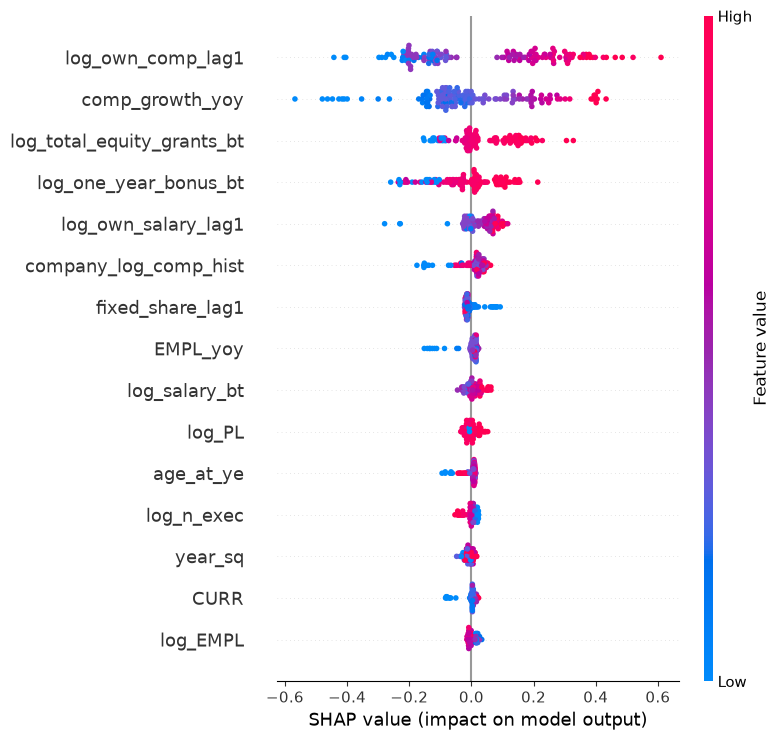

=== Non-CEO SHAP ===


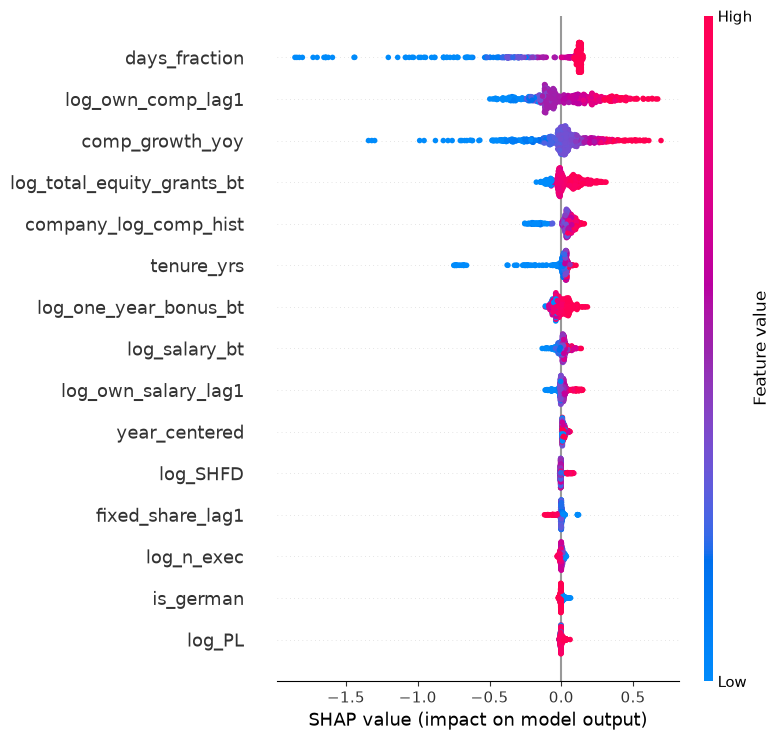

In [25]:
if ceo_r:
    print('=== CEO SHAP ===')
    shap.summary_plot(ceo_r['sv'], ceo_r['Xte'], max_display=15, show=True)

if nceo_r:
    print('=== Non-CEO SHAP ===')
    shap.summary_plot(nceo_r['sv'], nceo_r['Xte'], max_display=15, show=True)

## 10 · Compensation Structure Prediction

Separate LightGBM per share target (`fixed_share`, `sti_share`, `lti_share`).  
Key additions: lag share features, board-total context, interaction terms.

In [26]:
# Structure features: add lag shares + drop interaction terms that encode level
STRUCT_EXTRA = ['fixed_share_lag1', 'lti_share_lag1']
STRUCT_FEATURES = FEATURE_COLS.copy()

# Remove level-encoded board totals (they reveal the level, not structure)
level_cols = ['log_salary_bt','log_one_year_bonus_bt','log_total_equity_grants_bt',
              'log_own_comp_lag1','company_log_comp_hist']
STRUCT_FEATURES = [f for f in STRUCT_FEATURES if f not in level_cols]
STRUCT_FEATURES += [f for f in STRUCT_EXTRA if f in df.columns and f not in STRUCT_FEATURES]

print(f'Structure feature set: {len(STRUCT_FEATURES)} features')

# Dataset: valid comp_sum > 0 and all three targets
struct_mask = (
    mod[TARGET_STRUCTURE].notna().all(axis=1)
    & (mod['comp_sum'] > 10)
)
mod_s = mod[struct_mask].copy()
print(f'Structure modelling rows: {len(mod_s):,}')

tr_s = mod_s['year_num'] <= TRAIN_CUTOFF
te_s = mod_s['year_num'] >  TRAIN_CUTOFF
print(f'Train: {tr_s.sum():,}  Test: {te_s.sum():,}')

Structure feature set: 66 features
Structure modelling rows: 3,130
Train: 2,320  Test: 810


In [27]:
struct_results = {}
struct_shaps   = {}
colors_s       = {'fixed_share': '#2196F3', 'sti_share': '#FF9800', 'lti_share': '#4CAF50'}

imp_s = SimpleImputer(strategy='median').fit(mod_s.loc[tr_s, STRUCT_FEATURES])
Xs_tr = pd.DataFrame(imp_s.transform(mod_s.loc[tr_s, STRUCT_FEATURES]), columns=STRUCT_FEATURES)
Xs_te = pd.DataFrame(imp_s.transform(mod_s.loc[te_s, STRUCT_FEATURES]), columns=STRUCT_FEATURES)

# Inner val for early stopping (last 2 train years)
tr_s_inner = mod_s['year_num'] < (TRAIN_CUTOFF - 1)
val_s_inner = (mod_s['year_num'] >= (TRAIN_CUTOFF - 1)) & tr_s
Xs_ptr  = pd.DataFrame(imp_s.transform(mod_s.loc[tr_s_inner, STRUCT_FEATURES]), columns=STRUCT_FEATURES)
Xs_val  = pd.DataFrame(imp_s.transform(mod_s.loc[val_s_inner, STRUCT_FEATURES]), columns=STRUCT_FEATURES)

print('Structure target performance:')
for t in TARGET_STRUCTURE:
    ys_tr  = mod_s.loc[tr_s, t]
    ys_te  = mod_s.loc[te_s, t]
    ys_ptr = mod_s.loc[tr_s_inner, t]
    ys_val = mod_s.loc[val_s_inner, t]

    mdl_s = lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=8, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=SEED, verbose=-1
    )
    mdl_s.fit(Xs_ptr, ys_ptr,
              eval_set=[(Xs_val, ys_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])

    pred_s = mdl_s.predict(Xs_te).clip(0, 1)
    r2  = r2_score(ys_te, pred_s)
    mae = mean_absolute_error(ys_te, pred_s)
    struct_results[t] = {'r2': r2, 'mae': mae, 'model': mdl_s, 'pred': pred_s,
                          'y_te': ys_te, 'best_iter': mdl_s.best_iteration_}
    print(f'  {t:15s}  R²={r2:.3f}  MAE={mae:.3f}  best_iter={mdl_s.best_iteration_}')

    # SHAP
    expl_s = shap.TreeExplainer(mdl_s)
    sv_s   = expl_s.shap_values(Xs_te)
    struct_shaps[t] = sv_s

Structure target performance:


  fixed_share      R²=-1.218  MAE=0.148  best_iter=112


  sti_share        R²=-0.377  MAE=0.134  best_iter=70


  lti_share        R²=-0.035  MAE=0.116  best_iter=182


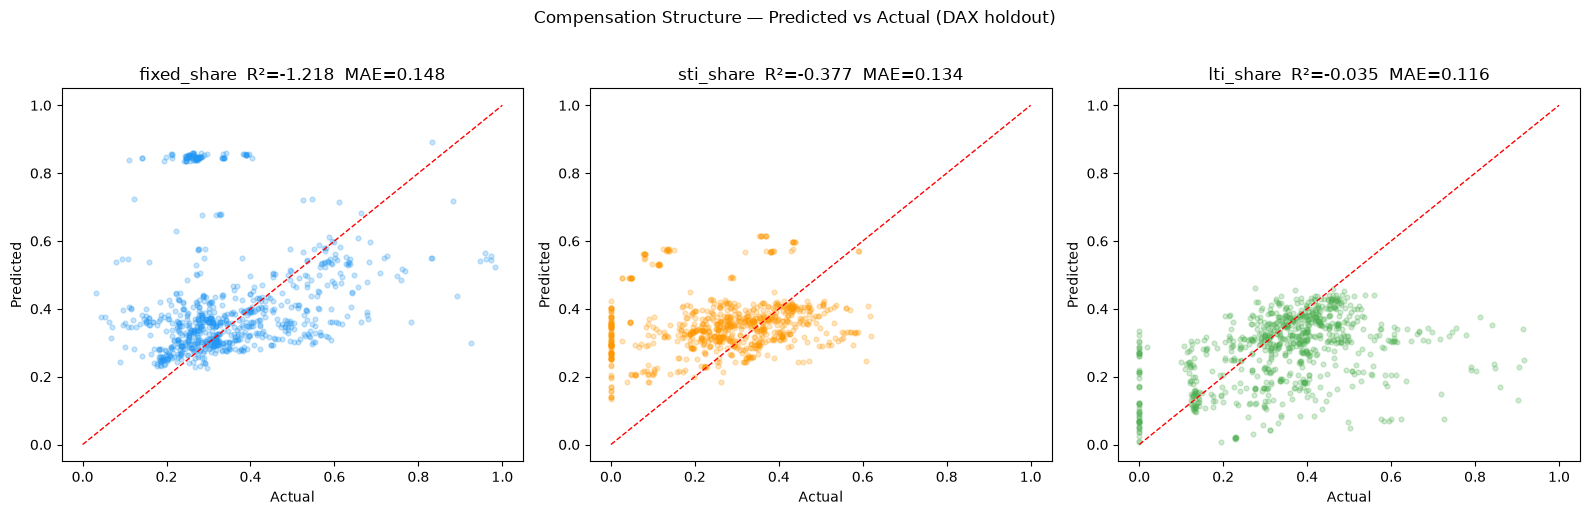

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, t in enumerate(TARGET_STRUCTURE):
    y_a = struct_results[t]['y_te'].values
    y_p = struct_results[t]['pred']
    axes[i].scatter(y_a, y_p, alpha=0.25, s=12, color=colors_s[t])
    axes[i].plot([0,1],[0,1],'r--',lw=1)
    axes[i].set_xlim(-0.05, 1.05); axes[i].set_ylim(-0.05, 1.05)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'{t}  R²={struct_results[t]["r2"]:.3f}  MAE={struct_results[t]["mae"]:.3f}')
plt.suptitle('Compensation Structure — Predicted vs Actual (DAX holdout)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

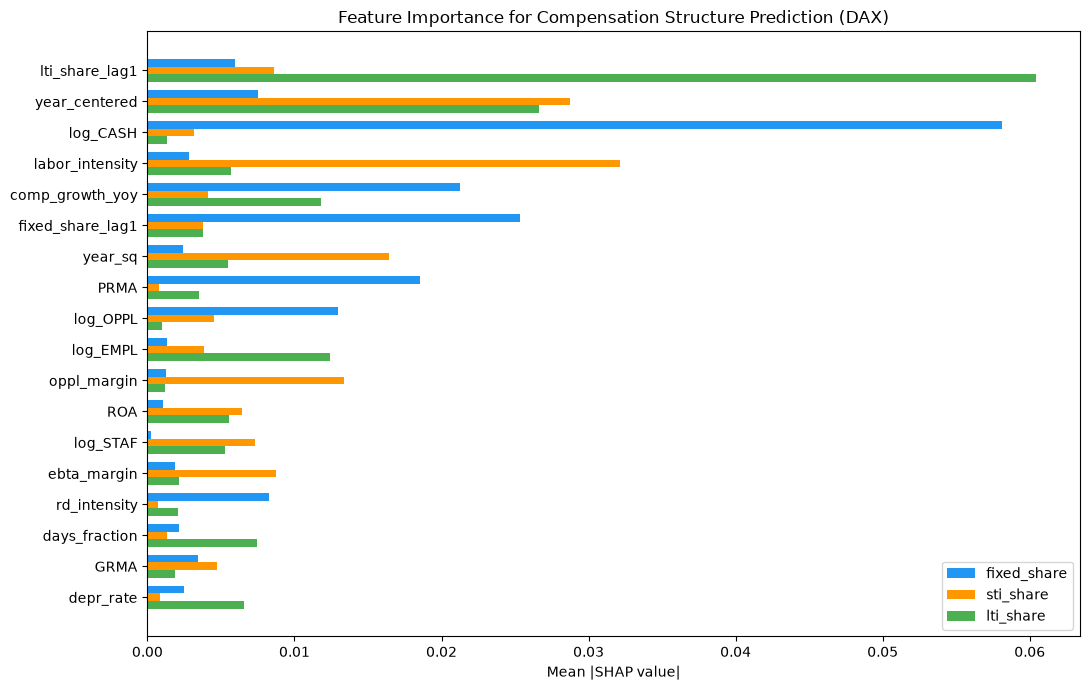

In [29]:
# SHAP importance grouped by structure target
struct_shap_df = {}
for t in TARGET_STRUCTURE:
    sv = struct_shaps[t]
    struct_shap_df[t] = pd.Series(np.abs(sv).mean(axis=0), index=STRUCT_FEATURES)

cmp_s = pd.DataFrame(struct_shap_df)
cmp_s['total'] = cmp_s.sum(axis=1)
cmp_s = cmp_s.sort_values('total', ascending=False).head(18)

fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(cmp_s))
w = 0.25
for i, t in enumerate(TARGET_STRUCTURE):
    ax.barh(x - w + i*w, cmp_s[t], w, label=t, color=list(colors_s.values())[i])
ax.set_yticks(x)
ax.set_yticklabels(cmp_s.index)
ax.invert_yaxis()
ax.legend()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance for Compensation Structure Prediction (DAX)')
plt.tight_layout()
plt.show()

=== SHAP beeswarm: fixed_share ===


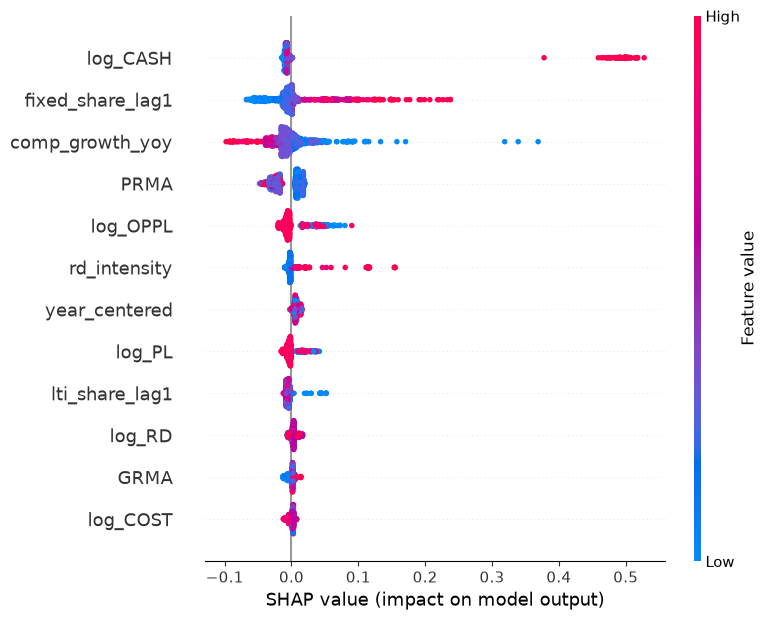

=== SHAP beeswarm: sti_share ===


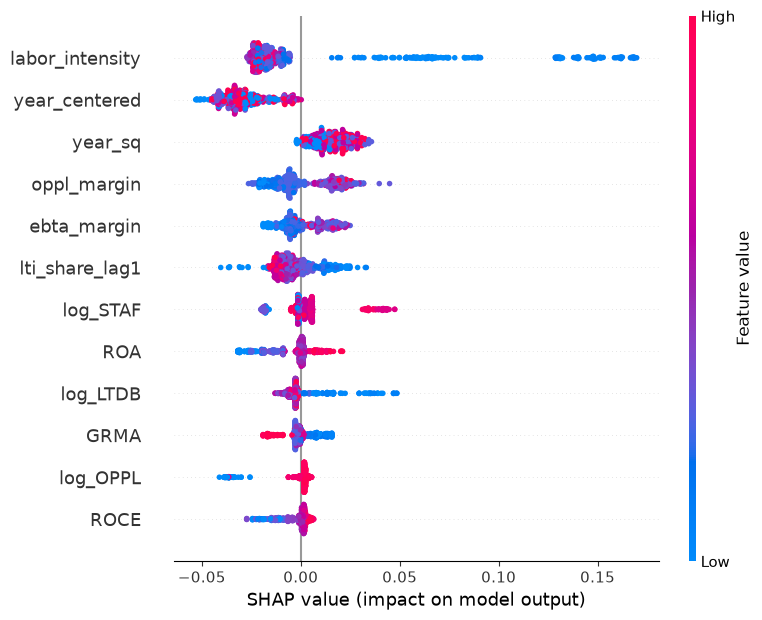

=== SHAP beeswarm: lti_share ===


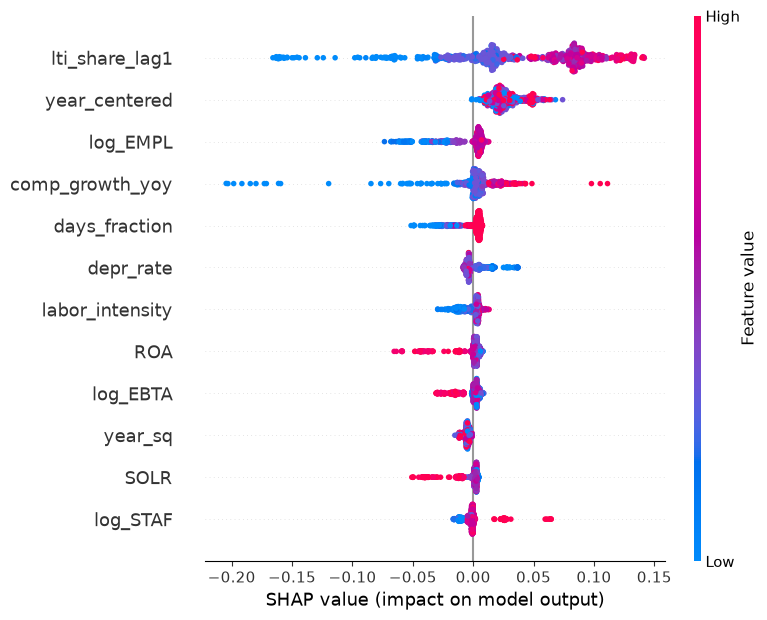

In [30]:
for t in TARGET_STRUCTURE:
    print(f'=== SHAP beeswarm: {t} ===')
    shap.summary_plot(struct_shaps[t], Xs_te, max_display=12, show=True)

## 11 · Feature Group Ablation

Which feature groups contribute the most? We retrain LightGBM removing one group at a time.

In [31]:
# Baseline: all features
imp_ab  = SimpleImputer(strategy='median').fit(X_train)
Xtr_ab  = imp_ab.transform(X_train)
Xte_ab  = imp_ab.transform(X_test)

def train_eval_lgb(Xtr, Xte, ytr, yte):
    mdl = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=7, num_leaves=31,
        n_jobs=-1, random_state=SEED, verbose=-1
    ).fit(Xtr, ytr)
    pred = mdl.predict(Xte)
    return r2_score(yte, pred), mean_absolute_error(np.expm1(yte), np.expm1(pred))

r2_base, mae_base = train_eval_lgb(Xtr_ab, Xte_ab, y_train, y_test)
print(f'Baseline (all features):  R²={r2_base:.3f}  MAE={mae_base:.0f}k')

ablation_rows = [{'group': 'ALL (baseline)', 'R²': r2_base, 'MAE_€k': mae_base, 'ΔR²': 0}]

for group, cols in FEATURES.items():
    avail = [c for c in cols if c in FEATURE_COLS]
    if not avail:
        continue
    remaining_cols = [c for c in FEATURE_COLS if c not in avail]
    if len(remaining_cols) < 5:
        continue

    rem_idx = [FEATURE_COLS.index(c) for c in remaining_cols]
    r2_ab, mae_ab = train_eval_lgb(
        Xtr_ab[:, rem_idx], Xte_ab[:, rem_idx], y_train, y_test
    )
    delta = r2_ab - r2_base
    ablation_rows.append({'group': f'drop {group}', 'R²': r2_ab, 'MAE_€k': mae_ab, 'ΔR²': delta})
    print(f'  drop {group:20s}  R²={r2_ab:.3f}  ΔR²={delta:+.3f}  MAE={mae_ab:.0f}k')

abl_df = pd.DataFrame(ablation_rows)
print()
print(abl_df.sort_values('ΔR²').to_string(index=False))

Baseline (all features):  R²=0.814  MAE=365k


  drop executive_role        R²=0.804  ΔR²=-0.010  MAE=342k


  drop demographics          R²=0.813  ΔR²=-0.001  MAE=374k


  drop board_context         R²=0.815  ΔR²=+0.001  MAE=367k


  drop company_size          R²=0.808  ΔR²=-0.006  MAE=363k


  drop ratios                R²=0.812  ΔR²=-0.002  MAE=367k


  drop yoy_growth            R²=0.814  ΔR²=-0.000  MAE=379k


  drop lag_comp              R²=0.683  ΔR²=-0.131  MAE=692k


  drop board_total           R²=0.781  ΔR²=-0.033  MAE=394k


  drop interactions          R²=0.810  ΔR²=-0.004  MAE=373k

              group    R²  MAE_€k    ΔR²
      drop lag_comp 0.683 692.013 -0.131
   drop board_total 0.781 393.518 -0.033
drop executive_role 0.804 341.989 -0.010
  drop company_size 0.808 363.299 -0.006
  drop interactions 0.810 372.644 -0.004
        drop ratios 0.812 366.521 -0.002
  drop demographics 0.813 373.692 -0.001
    drop yoy_growth 0.814 378.972 -0.000
     ALL (baseline) 0.814 365.217  0.000
 drop board_context 0.815 367.246  0.001


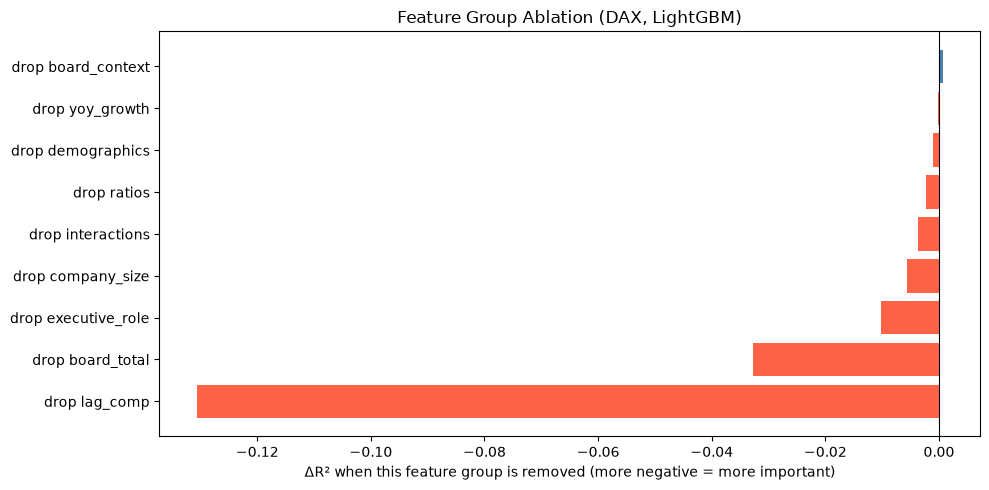

In [32]:
drop_df = abl_df[abl_df['group'] != 'ALL (baseline)'].sort_values('ΔR²')

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['tomato' if v < 0 else 'steelblue' for v in drop_df['ΔR²']]
ax.barh(range(len(drop_df)), drop_df['ΔR²'], color=bar_colors)
ax.set_yticks(range(len(drop_df)))
ax.set_yticklabels(drop_df['group'])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('ΔR² when this feature group is removed (more negative = more important)')
ax.set_title('Feature Group Ablation (DAX, LightGBM)')
plt.tight_layout()
plt.show()

## 12 · Summary

In [33]:
print('=' * 65)
print('EXECUTIVE COMPENSATION — DAX MODEL SUMMARY')
print('=' * 65)

print(f'\nDataset: {len(mod):,} person-year obs, {mod["company_shortname"].nunique()} companies')
print(f'Train: ≤{TRAIN_CUTOFF}  |  Test: >{TRAIN_CUTOFF}')
print(f'Features: {len(FEATURE_COLS)}')

print('\n─── A. Level model ──────────────────────────────────────────────')
for r in sorted(results, key=lambda x: -x['R²']):
    print(f"  {r['model']:25s}  R²={r['R²']:.3f}  MAE={r['MAE_€k']:.0f}k")

print(f'\n  CV (expanding window):  mean R²={cv_df["R²"].mean():.3f}  mean MAE={cv_df["MAE_€k"].mean():.0f}k')

print('\n─── B. Structure model (DAX holdout) ───────────────────────────')
for t in TARGET_STRUCTURE:
    sr = struct_results[t]
    print(f"  {t:15s}  R²={sr['r2']:.3f}  MAE={sr['mae']:.3f}")

print('\n─── C. Top 10 features (SHAP, LightGBM) ───────────────────────')
for _, row in shap_df.head(10).iterrows():
    print(f"  {row['feature']:30s}  mean|SHAP|={row['mean_abs_shap']:.4f}")

print('\n─── D. Most important feature groups (ablation) ────────────────')
drop_ranked = abl_df[abl_df['group'] != 'ALL (baseline)'].sort_values('ΔR²')
for _, row in drop_ranked.head(5).iterrows():
    print(f"  {row['group']:30s}  ΔR²={row['ΔR²']:+.3f}")

EXECUTIVE COMPENSATION — DAX MODEL SUMMARY

Dataset: 3,483 person-year obs, 56 companies
Train: ≤2017  |  Test: >2017
Features: 71

─── A. Level model ──────────────────────────────────────────────
  XGBoost                    R²=0.824  MAE=375k
  LightGBM (early-stop)      R²=0.822  MAE=360k
  RandomForest               R²=0.741  MAE=595k
  Lasso (CV-alpha)           R²=0.723  MAE=577k
  Ridge (CV-alpha)           R²=0.697  MAE=667k

  CV (expanding window):  mean R²=0.868  mean MAE=319k

─── B. Structure model (DAX holdout) ───────────────────────────
  fixed_share      R²=-1.218  MAE=0.148
  sti_share        R²=-0.377  MAE=0.134
  lti_share        R²=-0.035  MAE=0.116

─── C. Top 10 features (SHAP, LightGBM) ───────────────────────
  log_own_comp_lag1               mean|SHAP|=0.2196
  days_fraction                   mean|SHAP|=0.2117
  comp_growth_yoy                 mean|SHAP|=0.1395
  log_total_equity_grants_bt      mean|SHAP|=0.0813
  company_log_comp_hist           mean|SHAP|=0.

## 13 · Compensation Structure in the Data

Before modelling structure, let's understand what it actually looks like: how pay is split between fixed salary, short-term incentives, and long-term incentives — and how that varies by role, company size, and over time.

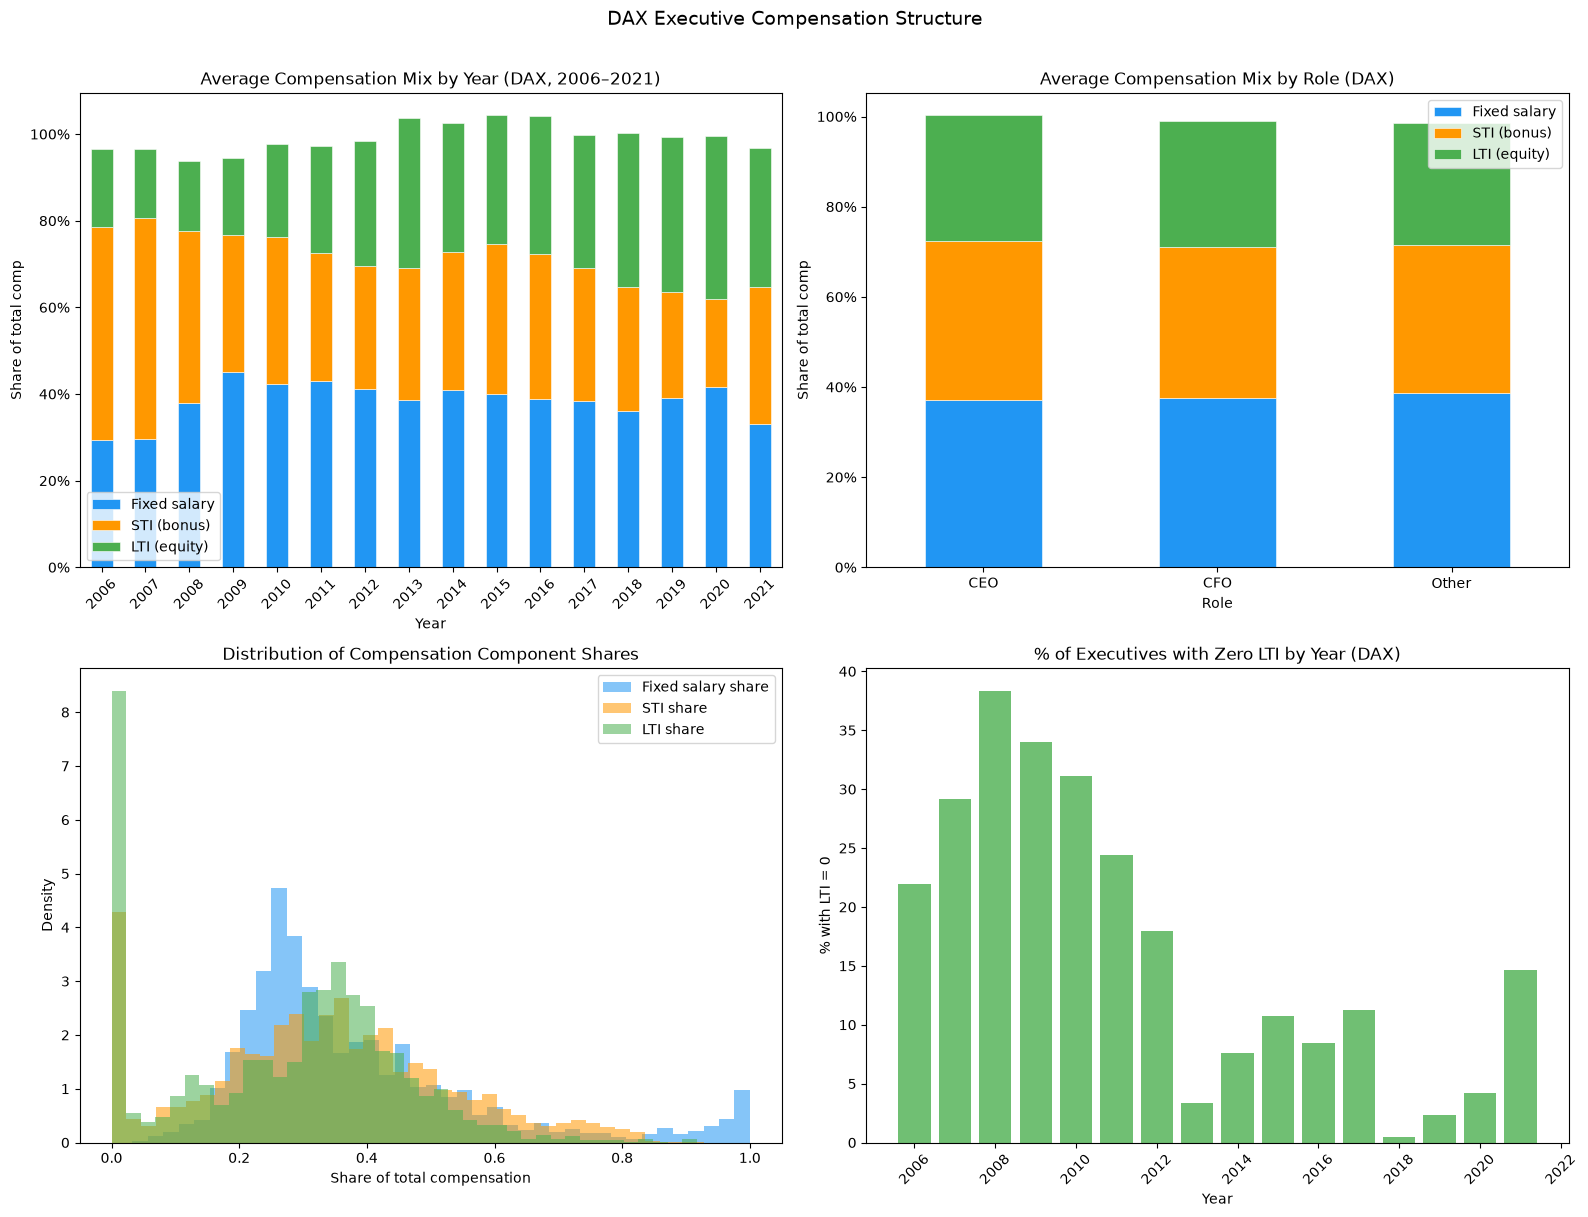


Mean compensation shares overall:
fixed_share   0.383
sti_share     0.333
lti_share     0.272
dtype: float64

Share of executives with zero LTI: 16.3%


In [34]:
# ── 13a · Structure overview ──────────────────────────────────────────────────
struct_vis = mod[mod['comp_sum'] > 10].copy()
struct_vis['role'] = np.where(struct_vis['is_ceo'] == 1, 'CEO',
                    np.where(struct_vis['is_cfo'] == 1, 'CFO', 'Other'))

# Mean shares by year
yr_struct = (
    struct_vis.groupby('year_num')[['fixed_share','sti_share','lti_share']]
    .mean()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Stacked bar by year
yr_struct.plot(
    kind='bar', stacked=True, ax=axes[0, 0],
    color=['#2196F3','#FF9800','#4CAF50'],
    edgecolor='white', linewidth=0.4
)
axes[0, 0].set_title('Average Compensation Mix by Year (DAX, 2006–2021)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Share of total comp')
axes[0, 0].legend(['Fixed salary', 'STI (bonus)', 'LTI (equity)'], loc='lower left')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# By role
role_struct = (
    struct_vis.groupby('role')[['fixed_share','sti_share','lti_share']]
    .mean()
    .loc[['CEO','CFO','Other']]
)
role_struct.plot(
    kind='bar', stacked=True, ax=axes[0, 1],
    color=['#2196F3','#FF9800','#4CAF50'],
    edgecolor='white', linewidth=0.4
)
axes[0, 1].set_title('Average Compensation Mix by Role (DAX)')
axes[0, 1].set_xlabel('Role')
axes[0, 1].set_ylabel('Share of total comp')
axes[0, 1].legend(['Fixed salary', 'STI (bonus)', 'LTI (equity)'])
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Distribution of each share
for col, color, label in [
    ('fixed_share', '#2196F3', 'Fixed salary share'),
    ('sti_share',   '#FF9800', 'STI share'),
    ('lti_share',   '#4CAF50', 'LTI share'),
]:
    axes[1, 0].hist(struct_vis[col].dropna(), bins=40, alpha=0.55,
                    color=color, label=label, density=True)
axes[1, 0].set_title('Distribution of Compensation Component Shares')
axes[1, 0].set_xlabel('Share of total compensation')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Share with zero LTI by year
zero_lti = struct_vis.groupby('year_num').apply(
    lambda g: (g['lti_share'] == 0).mean()
).rename('pct_zero_lti')
axes[1, 1].bar(zero_lti.index, zero_lti.values * 100, color='#4CAF50', alpha=0.8)
axes[1, 1].set_title('% of Executives with Zero LTI by Year (DAX)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('% with LTI = 0')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('DAX Executive Compensation Structure', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nMean compensation shares overall:')
print(struct_vis[['fixed_share','sti_share','lti_share']].mean().round(3))
print(f'\nShare of executives with zero LTI: {(struct_vis["lti_share"]==0).mean():.1%}')

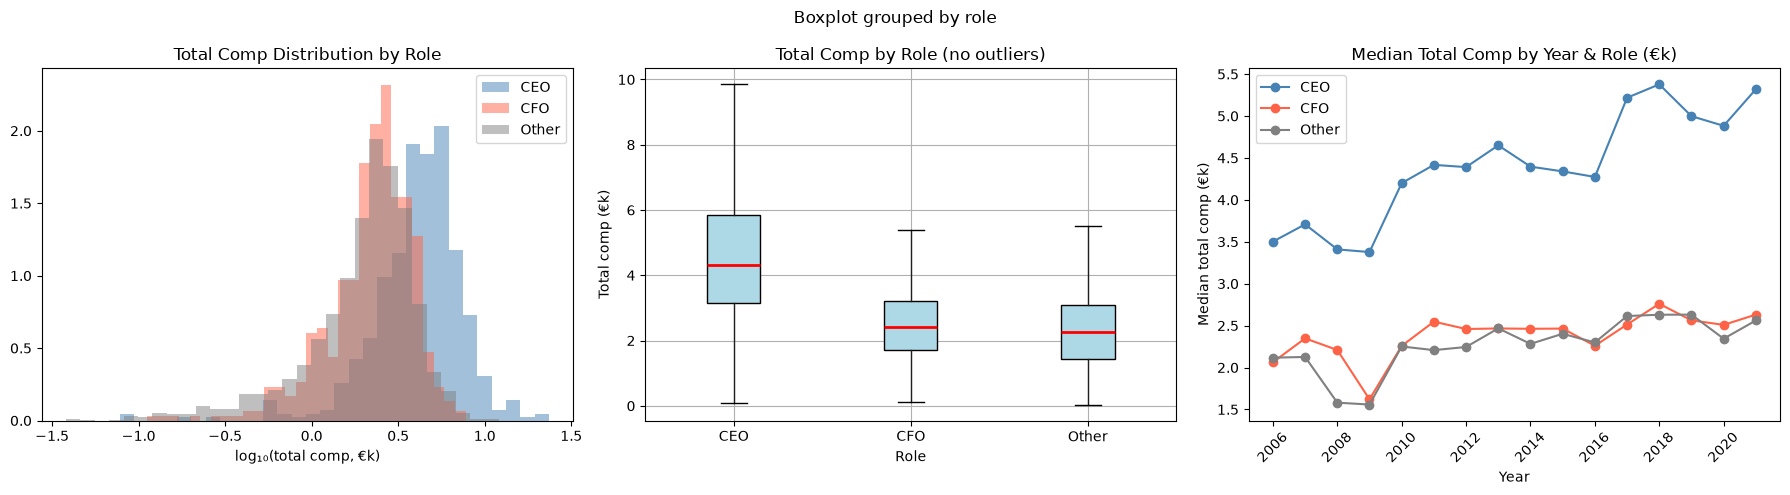


Compensation summary by role:
          n  median_comp_k  mean_fixed  mean_sti  mean_lti  pct_zero_lti
role                                                                    
CEO     513          4.325       0.370     0.353     0.279         0.148
CFO     486          2.424       0.375     0.335     0.279         0.130
Other  2484          2.268       0.387     0.328     0.270         0.173


In [35]:
# ── 13b · Level distributions by role & company size ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total comp distribution by role (log scale)
for role, color in [('CEO','steelblue'),('CFO','tomato'),('Other','gray')]:
    vals = struct_vis[struct_vis['role'] == role]['total_comp'].dropna()
    vals = vals[vals > 10] / 1000  # to €k
    axes[0].hist(np.log10(vals), bins=30, alpha=0.5, color=color, label=role, density=True)
axes[0].set_xlabel('log₁₀(total comp, €k)')
axes[0].set_title('Total Comp Distribution by Role')
axes[0].legend()

# Boxplot of comp by role
roles_plot = struct_vis[struct_vis['total_comp'] > 10].copy()
roles_plot['total_comp_k'] = roles_plot['total_comp'] / 1000
roles_plot.boxplot(
    column='total_comp_k', by='role', ax=axes[1],
    showfliers=False, patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2),
)
axes[1].set_title('Total Comp by Role (no outliers)')
axes[1].set_xlabel('Role')
axes[1].set_ylabel('Total comp (€k)')
plt.sca(axes[1]); plt.title('Total Comp by Role (no outliers)')

# Median total comp by year, by role
pivot_yr = (
    struct_vis[struct_vis['total_comp'] > 10]
    .groupby(['year_num','role'])['total_comp']
    .median()
    .unstack('role')
    / 1000
)
for col, color in zip(['CEO','CFO','Other'], ['steelblue','tomato','gray']):
    if col in pivot_yr.columns:
        axes[2].plot(pivot_yr.index, pivot_yr[col], marker='o', label=col, color=color)
axes[2].set_title('Median Total Comp by Year & Role (€k)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Median total comp (€k)')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table
summ = struct_vis[struct_vis['total_comp'] > 10].groupby('role').agg(
    n=('total_comp','count'),
    median_comp_k=('total_comp', lambda x: x.median() / 1000),
    mean_fixed=('fixed_share','mean'),
    mean_sti=('sti_share','mean'),
    mean_lti=('lti_share','mean'),
    pct_zero_lti=('lti_share', lambda x: (x == 0).mean()),
).round(3)
print('\nCompensation summary by role:')
print(summ.to_string())

## 14 · Company Fundamentals as Standalone Predictors

Can company-level fundamentals alone predict executive pay — without knowing anything about the executive themselves (no role, no tenure, no lag comp)?  
This answers: *"does firm size/performance drive pay, independent of who sits on the board?"*

In [36]:
# ── 14a · Define company-fundamentals feature set ─────────────────────────────
# Include: ORBIS size, ratios, YoY growth, board headcount, year
# Exclude: executive demographics, role flags, ANY lag compensation
COMPANY_FEATURES = (
    FEATURES['company_size'] +   # log TURN, TOAS, EMPL, etc.
    FEATURES['ratios'] +         # ROE, ROA, margins, leverage
    FEATURES['yoy_growth'] +     # YoY revenue/profit/employment growth
    FEATURES['board_context']    # log_n_exec, year_centered — board-level, not person-level
)
# Keep only columns that exist
COMPANY_FEATURES = [c for c in COMPANY_FEATURES if c in df.columns]
print(f'Company-fundamentals feature set: {len(COMPANY_FEATURES)} features')
print(COMPANY_FEATURES)

# Train/test using the same mod subset and cutoff
Xc_train = mod.loc[train_mask, COMPANY_FEATURES]
Xc_test  = mod.loc[test_mask,  COMPANY_FEATURES]

imp_c = SimpleImputer(strategy='median').fit(Xc_train)
Xc_tr_f = imp_c.transform(Xc_train)
Xc_te_f = imp_c.transform(Xc_test)

# Also compare aggregate (company-year mean) R²: how well does one set of
# company fundamentals explain the mean pay at that company in that year?
comp_yr = (
    mod.groupby(['isin','year_num'])[COMPANY_FEATURES + [TARGET_AMOUNT]]
    .mean()
    .dropna(subset=[TARGET_AMOUNT])
    .reset_index()
)
tr_cy = comp_yr['year_num'] <= TRAIN_CUTOFF
te_cy = comp_yr['year_num'] >  TRAIN_CUTOFF
Xcy_tr = imp_c.transform(comp_yr.loc[tr_cy, COMPANY_FEATURES])
Xcy_te = imp_c.transform(comp_yr.loc[te_cy, COMPANY_FEATURES])
ycy_tr = comp_yr.loc[tr_cy, TARGET_AMOUNT]
ycy_te = comp_yr.loc[te_cy, TARGET_AMOUNT]
print(f'\nCompany-year aggregate dataset: {len(comp_yr)} rows (train {tr_cy.sum()}, test {te_cy.sum()})')

Company-fundamentals feature set: 46 features
['log_TURN', 'log_TOAS', 'log_EMPL', 'log_STAF', 'log_EBTA', 'log_OPPL', 'log_PL', 'log_SHFD', 'log_LTDB', 'log_CASH', 'log_DEPR', 'log_RD', 'log_CF', 'log_COST', 'ROE', 'ROA', 'ROCE', 'PRMA', 'GRMA', 'CURR', 'SOLR', 'GEAR', 'oppl_margin', 'ebta_margin', 'staf_per_empl', 'labor_intensity', 'cash_ratio', 'depr_rate', 'interest_coverage', 'rd_intensity', 'debt_to_assets', 'debt_to_equity', 'revenue_per_empl', 'TURN_yoy', 'TOAS_yoy', 'EMPL_yoy', 'OPPL_yoy', 'PL_yoy', 'STAF_yoy', 'ROE_yoy', 'ROCE_yoy', 'log_n_exec', 'n_exec_sq', 'opting_out', 'year_centered', 'year_sq']

Company-year aggregate dataset: 502 rows (train 369, test 133)


In [37]:
# ── 14b · Train models — company fundamentals only ────────────────────────────
from sklearn.preprocessing import StandardScaler as SS

scaler_c = SS().fit(Xc_tr_f)
Xc_tr_sc = scaler_c.transform(Xc_tr_f)
Xc_te_sc = scaler_c.transform(Xc_te_f)

fund_results = []

# Ridge
ridge_c = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]).fit(Xc_tr_sc, y_train)
pred_rc = ridge_c.predict(Xc_te_sc)
r2_rc   = r2_score(y_test, pred_rc)
mae_rc  = mean_absolute_error(np.expm1(y_test), np.expm1(pred_rc))
fund_results.append({'model': 'Ridge (company only)', 'R²': r2_rc, 'MAE_€k': mae_rc})
print(f'Ridge (company only):       R²={r2_rc:.3f}  MAE={mae_rc:.0f}k')

# LightGBM
lgb_c = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=6,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=SEED, verbose=-1
).fit(Xc_tr_f, y_train)
pred_lc = lgb_c.predict(Xc_te_f)
r2_lc   = r2_score(y_test, pred_lc)
mae_lc  = mean_absolute_error(np.expm1(y_test), np.expm1(pred_lc))
fund_results.append({'model': 'LightGBM (company only)', 'R²': r2_lc, 'MAE_€k': mae_lc})
print(f'LightGBM (company only):    R²={r2_lc:.3f}  MAE={mae_lc:.0f}k')

# LightGBM on company-year aggregates
lgb_cy = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=5,
    num_leaves=15, n_jobs=-1, random_state=SEED, verbose=-1
).fit(Xcy_tr, ycy_tr)
pred_cy = lgb_cy.predict(Xcy_te)
r2_cy   = r2_score(ycy_te, pred_cy)
mae_cy  = mean_absolute_error(np.expm1(ycy_te), np.expm1(pred_cy))
fund_results.append({'model': 'LightGBM (company-year avg)', 'R²': r2_cy, 'MAE_€k': mae_cy})
print(f'LightGBM (company-yr avg): R²={r2_cy:.3f}  MAE={mae_cy:.0f}k')

# Full LightGBM for reference
print(f'\nFull model (all 71 features):   R²={max(r["R²"] for r in results):.3f}  (LightGBM/XGBoost)')

print('\n─── Interpretation ───────────────────────────────────────────────')
print(f'Company fundamentals alone explain {r2_lc:.1%} of variance in individual pay')
print(f'(company-year averages): {r2_cy:.1%} of company-level pay variance')
print(f'Remaining gap vs full model: {max(r["R²"] for r in results) - r2_lc:.1%} explained by executive-specific factors')

Ridge (company only):       R²=-0.469  MAE=1905k


LightGBM (company only):    R²=0.056  MAE=1279k


LightGBM (company-yr avg): R²=0.113  MAE=870k

Full model (all 71 features):   R²=0.824  (LightGBM/XGBoost)

─── Interpretation ───────────────────────────────────────────────
Company fundamentals alone explain 5.6% of variance in individual pay
(company-year averages): 11.3% of company-level pay variance
Remaining gap vs full model: 76.8% explained by executive-specific factors


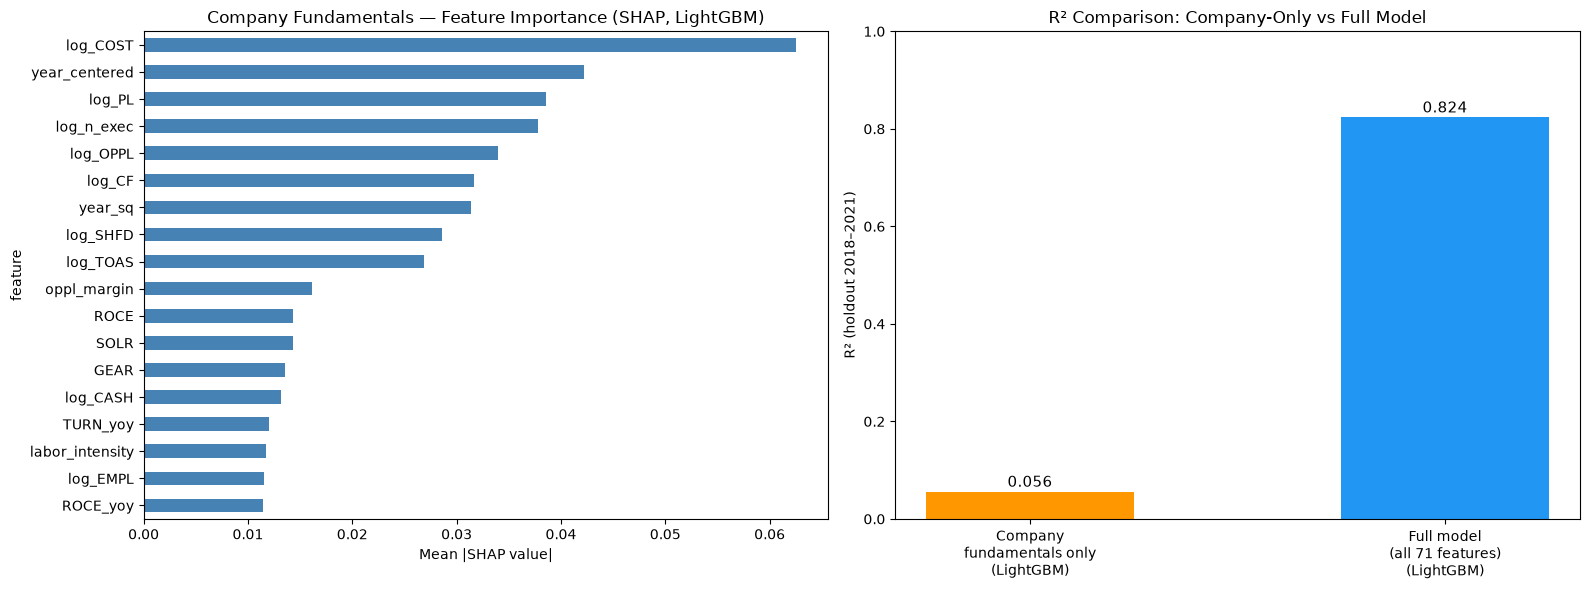


Top 10 most important company fundamentals:
      feature  mean_abs_shap
     log_COST          0.063
year_centered          0.042
       log_PL          0.039
   log_n_exec          0.038
     log_OPPL          0.034
       log_CF          0.032
      year_sq          0.031
     log_SHFD          0.029
     log_TOAS          0.027
  oppl_margin          0.016


In [38]:
# ── 14c · SHAP on company-fundamentals model ──────────────────────────────────
expl_c = shap.TreeExplainer(lgb_c)
sv_c   = expl_c.shap_values(pd.DataFrame(Xc_te_f, columns=COMPANY_FEATURES))

shap_c_df = pd.DataFrame({'feature': COMPANY_FEATURES,
                           'mean_abs_shap': np.abs(sv_c).mean(axis=0)})\
              .sort_values('mean_abs_shap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP bar chart
shap_c_df.head(18).sort_values('mean_abs_shap').plot(
    x='feature', y='mean_abs_shap', kind='barh',
    ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Company Fundamentals — Feature Importance (SHAP, LightGBM)')
axes[0].set_xlabel('Mean |SHAP value|')

# R² comparison: company-only vs full model
labels = ['Company\nfundamentals only\n(LightGBM)', 'Full model\n(all 71 features)\n(LightGBM)']
r2_vals = [r2_lc, max(r['R²'] for r in results)]
bar_cols = ['#FF9800', '#2196F3']
bars = axes[1].bar(labels, r2_vals, color=bar_cols, width=0.5)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('R² (holdout 2018–2021)')
axes[1].set_title('R² Comparison: Company-Only vs Full Model')
for b, v in zip(bars, r2_vals):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print('\nTop 10 most important company fundamentals:')
print(shap_c_df.head(10).to_string(index=False))

## 15 · Improved Compensation Structure Prediction

The original structure models all had negative R² — the model predicted worse than just using the mean.  
Root cause: compensation mix is a **company policy** decision that changes slowly over time; individual financial features don't capture it well.

Key improvements:
1. **Board-level structure ratios**: `lti_share_bt = total_equity_grants_bt / total_comp_bt` — the actual LTI share *across the whole board* in a given year, which reveals the company's compensation policy
2. **Company structure target encoding** (expanding window): historical average LTI/fixed share at the same company before the current year — captures persistent policy preferences
3. **Lag structure shares** (already in data): individual executive's share in year t-1

In [39]:
# ── 15a · Engineer board-level structure features ─────────────────────────────
# Board-level structure ratios (reveal the company's pay policy in that year)
df2 = mod.copy()

# These are already clipped and log-transformed; recompute ratios from raw values
for bt_col, raw_col in [
    ('total_equity_grants_bt', 'total_equity_grants'),
    ('one_year_bonus_bt', 'one_year_bonus'),
    ('salary_bt', 'salary'),
]:
    pass  # columns are already in mod from Section 2

df2['lti_share_bt']   = (df2['total_equity_grants_bt'] / df2['total_comp_bt'].replace(0, np.nan)).clip(0, 1)
df2['sti_share_bt']   = (df2['one_year_bonus_bt']      / df2['total_comp_bt'].replace(0, np.nan)).clip(0, 1)
df2['fixed_share_bt'] = (df2['salary_bt']              / df2['total_comp_bt'].replace(0, np.nan)).clip(0, 1)

fill_bt = df2[['lti_share_bt','sti_share_bt','fixed_share_bt']].notna().mean()
print('Board-level structure ratios fill rate:')
print(fill_bt.round(3))

# Expanding-window company structure target encoding (no leakage)
# For each row, use the historical median LTI/fixed share at the same company
df2_sorted = df2.sort_values('year_num').copy()

for share_col in ['lti_share', 'fixed_share', 'sti_share']:
    hist_col = f'company_{share_col}_hist'
    global_med = df2_sorted[share_col].median()
    hist_vals  = []
    for idx, row in df2_sorted.iterrows():
        past = df2_sorted.loc[
            (df2_sorted['isin'] == row['isin']) & (df2_sorted['year_num'] < row['year_num']),
            share_col
        ]
        hist_vals.append(past.median() if len(past) > 0 else global_med)
    df2_sorted[hist_col] = hist_vals
    fill = df2_sorted[hist_col].notna().mean()
    print(f'{hist_col}: fill={fill:.2%}')

df2 = df2_sorted
print('\nNew structure features engineered.')

Board-level structure ratios fill rate:
lti_share_bt     1.000
sti_share_bt     1.000
fixed_share_bt   1.000
dtype: float64


company_lti_share_hist: fill=100.00%


company_fixed_share_hist: fill=100.00%


company_sti_share_hist: fill=99.91%

New structure features engineered.


In [40]:
# ── 15b · Build improved structure feature set ────────────────────────────────
# Core structure-specific features: board ratios + company history + individual lag
STRUCT_POLICY_FEATURES = [
    'lti_share_bt', 'sti_share_bt', 'fixed_share_bt',      # board-level ratios (policy)
    'company_lti_share_hist', 'company_fixed_share_hist',   # company history (expanding window)
    'fixed_share_lag1', 'lti_share_lag1',                    # individual lag shares
]

# Combine with the original structure feature set (minus the problematic level features)
STRUCT_FEAT_V2 = STRUCT_FEATURES.copy()
# Add new policy features
for f in STRUCT_POLICY_FEATURES:
    if f not in STRUCT_FEAT_V2 and f in df2.columns:
        STRUCT_FEAT_V2.append(f)

# Filter to valid rows
struct_mask2 = (
    df2[TARGET_STRUCTURE].notna().all(axis=1)
    & (df2['comp_sum'] > 10)
)
mod_s2 = df2[struct_mask2].copy()
tr_s2  = mod_s2['year_num'] <= TRAIN_CUTOFF
te_s2  = mod_s2['year_num'] >  TRAIN_CUTOFF

print(f'Structure v2 rows: {len(mod_s2):,}  (train {tr_s2.sum()}, test {te_s2.sum()})')
print(f'Structure v2 feature set: {len(STRUCT_FEAT_V2)} features')
print(f'\nNew policy features (all available):')
for f in STRUCT_POLICY_FEATURES:
    avail = f in df2.columns
    fill  = df2[f].notna().mean() if avail else 0
    print(f'  {f:35s}  available={avail}  fill={fill:.1%}')

Structure v2 rows: 3,130  (train 2320, test 810)
Structure v2 feature set: 71 features

New policy features (all available):
  lti_share_bt                         available=True  fill=100.0%
  sti_share_bt                         available=True  fill=100.0%
  fixed_share_bt                       available=True  fill=100.0%
  company_lti_share_hist               available=True  fill=100.0%
  company_fixed_share_hist             available=True  fill=100.0%
  fixed_share_lag1                     available=True  fill=78.4%
  lti_share_lag1                       available=True  fill=74.5%


In [41]:
# ── 15c · Train improved structure models ─────────────────────────────────────
imp_s2 = SimpleImputer(strategy='median').fit(mod_s2.loc[tr_s2, STRUCT_FEAT_V2])
Xs2_tr = pd.DataFrame(imp_s2.transform(mod_s2.loc[tr_s2, STRUCT_FEAT_V2]), columns=STRUCT_FEAT_V2)
Xs2_te = pd.DataFrame(imp_s2.transform(mod_s2.loc[te_s2, STRUCT_FEAT_V2]), columns=STRUCT_FEAT_V2)

# Inner val for early stopping
tr_s2_inner  = (mod_s2['year_num'] < (TRAIN_CUTOFF - 1)) & tr_s2
val_s2_inner = (mod_s2['year_num'] >= (TRAIN_CUTOFF - 1)) & tr_s2
Xs2_ptr = pd.DataFrame(imp_s2.transform(mod_s2.loc[tr_s2_inner, STRUCT_FEAT_V2]), columns=STRUCT_FEAT_V2)
Xs2_val = pd.DataFrame(imp_s2.transform(mod_s2.loc[val_s2_inner, STRUCT_FEAT_V2]), columns=STRUCT_FEAT_V2)

struct_results_v2 = {}
struct_shaps_v2   = {}

print('Structure v2 performance comparison:')
print(f'{"Target":15s}  {"Old R²":>8s}  {"New R²":>8s}  {"Δ R²":>8s}  {"New MAE":>9s}')
print('-' * 60)

for t in TARGET_STRUCTURE:
    ys2_tr  = mod_s2.loc[tr_s2, t]
    ys2_te  = mod_s2.loc[te_s2, t]
    ys2_ptr = mod_s2.loc[tr_s2_inner, t]
    ys2_val = mod_s2.loc[val_s2_inner, t]

    mdl_v2 = lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=8, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=SEED, verbose=-1
    )
    mdl_v2.fit(
        Xs2_ptr, ys2_ptr,
        eval_set=[(Xs2_val, ys2_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )

    pred_v2  = mdl_v2.predict(Xs2_te).clip(0, 1)
    r2_v2    = r2_score(ys2_te, pred_v2)
    mae_v2   = mean_absolute_error(ys2_te, pred_v2)
    r2_old   = struct_results[t]['r2']
    delta_r2 = r2_v2 - r2_old

    struct_results_v2[t] = {'r2': r2_v2, 'mae': mae_v2, 'model': mdl_v2,
                             'pred': pred_v2, 'y_te': ys2_te}
    print(f'{t:15s}  {r2_old:>8.3f}  {r2_v2:>8.3f}  {delta_r2:>+8.3f}  {mae_v2:>9.3f}')

    expl_v2     = shap.TreeExplainer(mdl_v2)
    sv_v2       = expl_v2.shap_values(Xs2_te)
    struct_shaps_v2[t] = sv_v2

Structure v2 performance comparison:
Target             Old R²    New R²      Δ R²    New MAE
------------------------------------------------------------


fixed_share        -1.218     0.486    +1.703      0.071


sti_share          -0.377     0.809    +1.186      0.045


lti_share          -0.035     0.674    +0.709      0.056


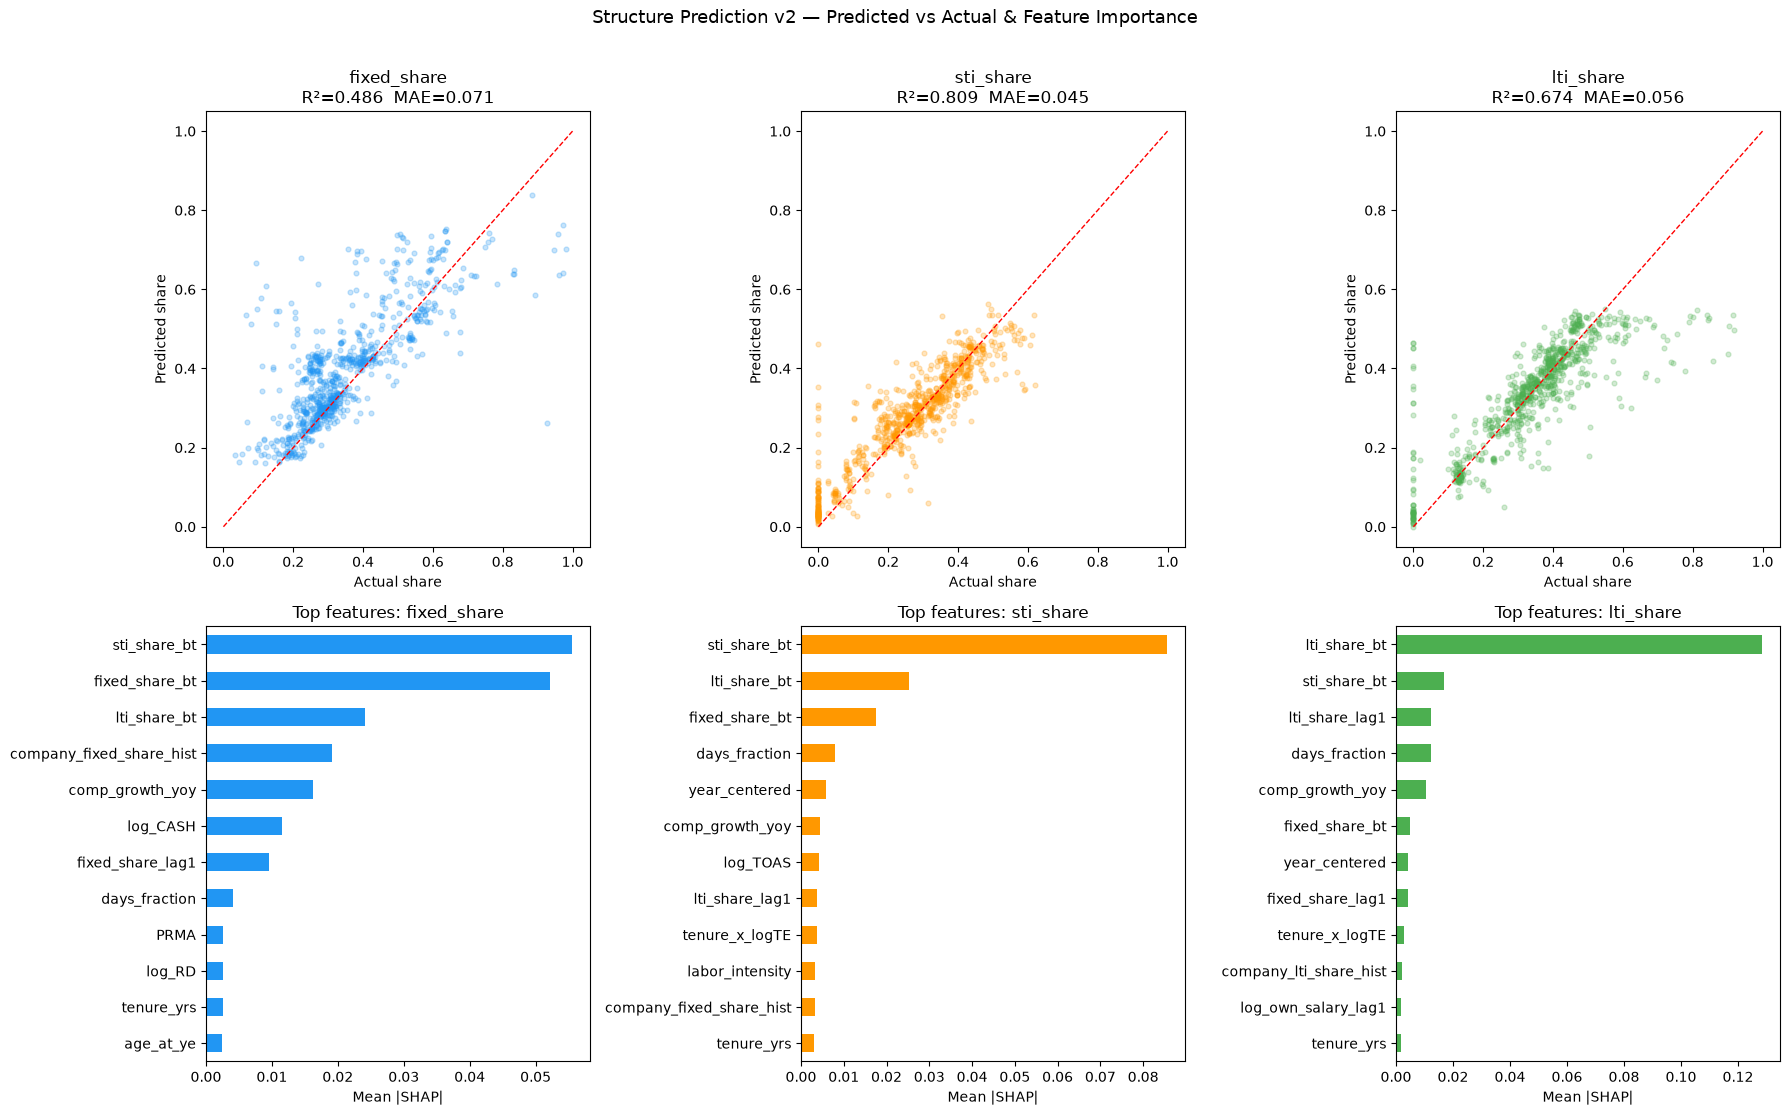


=== Structure Model Summary: v1 vs v2 ===
Target              v1 R²     v2 R²     v1 MAE     v2 MAE
------------------------------------------------------------
fixed_share        -1.218     0.486      0.148      0.071
sti_share          -0.377     0.809      0.134      0.045
lti_share          -0.035     0.674      0.116      0.056


In [42]:
# ── 15d · Visualise improved structure predictions ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for i, t in enumerate(TARGET_STRUCTURE):
    # Top row: predicted vs actual
    y_a = struct_results_v2[t]['y_te'].values
    y_p = struct_results_v2[t]['pred']
    r2  = struct_results_v2[t]['r2']
    mae = struct_results_v2[t]['mae']
    col = list(colors_s.values())[i]

    axes[0, i].scatter(y_a, y_p, alpha=0.25, s=12, color=col)
    axes[0, i].plot([0,1],[0,1],'r--',lw=1)
    axes[0, i].set_xlim(-0.05, 1.05); axes[0, i].set_ylim(-0.05, 1.05)
    axes[0, i].set_xlabel('Actual share')
    axes[0, i].set_ylabel('Predicted share')
    axes[0, i].set_title(f'{t}\nR²={r2:.3f}  MAE={mae:.3f}')

    # Bottom row: SHAP importance
    sv = struct_shaps_v2[t]
    imp_v2 = pd.Series(np.abs(sv).mean(axis=0), index=STRUCT_FEAT_V2)\
               .sort_values(ascending=False).head(12)
    imp_v2.sort_values().plot(kind='barh', ax=axes[1, i], color=col, legend=False)
    axes[1, i].set_title(f'Top features: {t}')
    axes[1, i].set_xlabel('Mean |SHAP|')

plt.suptitle('Structure Prediction v2 — Predicted vs Actual & Feature Importance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary: old vs new
print('\n=== Structure Model Summary: v1 vs v2 ===')
print(f'{"Target":15s}  {"v1 R²":>8s}  {"v2 R²":>8s}  {"v1 MAE":>9s}  {"v2 MAE":>9s}')
print('-' * 60)
for t in TARGET_STRUCTURE:
    r1 = struct_results[t]
    r2 = struct_results_v2[t]
    print(f'{t:15s}  {r1["r2"]:>8.3f}  {r2["r2"]:>8.3f}  {r1["mae"]:>9.3f}  {r2["mae"]:>9.3f}')

## 16 · Predicting Average Board Compensation from Company Fundamentals

Section 14 showed that company fundamentals explain only ~6% of **individual** pay variance — but individual pay is noisy (days in role, who happens to sit on the board, etc.).

Here we ask a cleaner question: can we predict the **average compensation per board member** () for a given company-year purely from ORBIS financials?  
This aggregates away individual noise and tests whether company size/performance drives the total cost of the executive team.

## 16 · Predicting Average Board Compensation from Company Fundamentals

Section 14 showed that company fundamentals explain only ~6% of **individual** pay variance — but individual pay is noisy (days in role, who happens to sit on the board, etc.).

Here we ask a cleaner question: can we predict the **average compensation per board member** (`total_comp_bt / n_executives`) for a given company-year purely from ORBIS financials?  
This aggregates away individual noise and tests whether company size/performance drives the total cost of the executive team.

In [46]:
# ── 16a · Build company-year board pay dataset ───────────────────────────────
# total_comp_bt = total pay for all board members at the company in that year.
# Dividing by n_executives gives average pay per board seat — one number per company-year.
# ORBIS financials are already company-level, so we just deduplicate on (isin, year_num).

board_base_cols = ['isin', 'company_shortname', 'year_num',
                   'total_comp_bt', 'salary_bt', 'one_year_bonus_bt',
                   'total_equity_grants_bt', 'n_executives']

cy = (
    df[board_base_cols + COMPANY_FEATURES]
    .drop_duplicates(subset=['isin', 'year_num'])
    .copy()
)
cy['total_comp_bt']        = pd.to_numeric(cy['total_comp_bt'],  errors='coerce').clip(lower=0)
cy['n_exec_cy']            = pd.to_numeric(cy['n_executives'],   errors='coerce')
cy['avg_board_comp']       = cy['total_comp_bt'] / cy['n_exec_cy'].replace(0, np.nan)
cy['log_avg_board_comp']   = np.log1p(cy['avg_board_comp'].clip(lower=0))
cy['log_total_board_comp'] = np.log1p(cy['total_comp_bt'])

valid_cy = cy[cy['log_avg_board_comp'].notna() & (cy['avg_board_comp'] > 10)].copy()
print(f"Company-year dataset: {len(valid_cy):,} rows "
      f"({valid_cy['isin'].nunique()} companies, "
      f"years {int(valid_cy['year_num'].min())}–{int(valid_cy['year_num'].max())})")
print(f"Avg board comp  median={valid_cy['avg_board_comp'].median()/1000:.0f}k  "
      f"mean={valid_cy['avg_board_comp'].mean()/1000:.0f}k")

tr_cy2 = valid_cy['year_num'] <= TRAIN_CUTOFF
te_cy2 = valid_cy['year_num'] >  TRAIN_CUTOFF
print(f"Train: {tr_cy2.sum()} rows  |  Test: {te_cy2.sum()} rows")

TARGET_BOARD = 'log_avg_board_comp'
Xb_tr_df = valid_cy.loc[tr_cy2, COMPANY_FEATURES]
Xb_te_df = valid_cy.loc[te_cy2, COMPANY_FEATURES]
yb_tr    = valid_cy.loc[tr_cy2, TARGET_BOARD]
yb_te    = valid_cy.loc[te_cy2, TARGET_BOARD]

imp_b    = SimpleImputer(strategy='median').fit(Xb_tr_df)
Xb_tr_f  = imp_b.transform(Xb_tr_df)
Xb_te_f  = imp_b.transform(Xb_te_df)

scaler_b = SS().fit(Xb_tr_f)
Xb_tr_sc = scaler_b.transform(Xb_tr_f)
Xb_te_sc = scaler_b.transform(Xb_te_f)


Company-year dataset: 502 rows (56 companies, years 2006–2021)
Avg board comp  median=3k  mean=3k
Train: 369 rows  |  Test: 133 rows


In [47]:
# ── 16b · Train models on board-level target ─────────────────────────────────
board_perf = []

# Ridge
ridge_b = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]).fit(Xb_tr_sc, yb_tr)
pred_rb  = ridge_b.predict(Xb_te_sc)
r2_rb    = r2_score(yb_te, pred_rb)
mae_rb   = mean_absolute_error(np.expm1(yb_te), np.expm1(pred_rb))
board_perf.append({'model': 'Ridge',    'R2': r2_rb,    'MAE_k': mae_rb})
print(f'Ridge:    R\u00b2={r2_rb:.3f}  MAE={mae_rb:.0f}k')

# Lasso (gives us linear coefficients too)
lasso_b = LassoCV(cv=5, max_iter=5000).fit(Xb_tr_sc, yb_tr)
pred_lb  = lasso_b.predict(Xb_te_sc)
r2_lb    = r2_score(yb_te, pred_lb)
mae_lb   = mean_absolute_error(np.expm1(yb_te), np.expm1(pred_lb))
board_perf.append({'model': 'Lasso',    'R2': r2_lb,    'MAE_k': mae_lb})
print(f'Lasso:    R\u00b2={r2_lb:.3f}  MAE={mae_lb:.0f}k')

# LightGBM
lgb_b = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.03, max_depth=5, num_leaves=15,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=5,
    n_jobs=-1, random_state=SEED, verbose=-1
).fit(Xb_tr_f, yb_tr)
pred_lgb_b = lgb_b.predict(Xb_te_f)
r2_lgb_b   = r2_score(yb_te, pred_lgb_b)
mae_lgb_b  = mean_absolute_error(np.expm1(yb_te), np.expm1(pred_lgb_b))
board_perf.append({'model': 'LightGBM', 'R2': r2_lgb_b, 'MAE_k': mae_lgb_b})
print(f'LightGBM: R\u00b2={r2_lgb_b:.3f}  MAE={mae_lgb_b:.0f}k')

print()
print(f'Compare:')
print(f'  Individual pay  (company features only, LightGBM): R\u00b2={r2_lc:.3f}  MAE={mae_lc:.0f}k')
print(f'  Board avg pay   (company features only, LightGBM): R\u00b2={r2_lgb_b:.3f}  MAE={mae_lgb_b:.0f}k')
print(f'  Individual pay  (all 71 features, LightGBM):       R\u00b2={max(r["R\u00b2"] for r in results):.3f}')


Ridge:    R²=-0.876  MAE=1715k
Lasso:    R²=-0.362  MAE=873k
LightGBM: R²=0.170  MAE=813k

Compare:
  Individual pay  (company features only, LightGBM): R²=0.056  MAE=1279k
  Board avg pay   (company features only, LightGBM): R²=0.170  MAE=813k
  Individual pay  (all 71 features, LightGBM):       R²=0.824


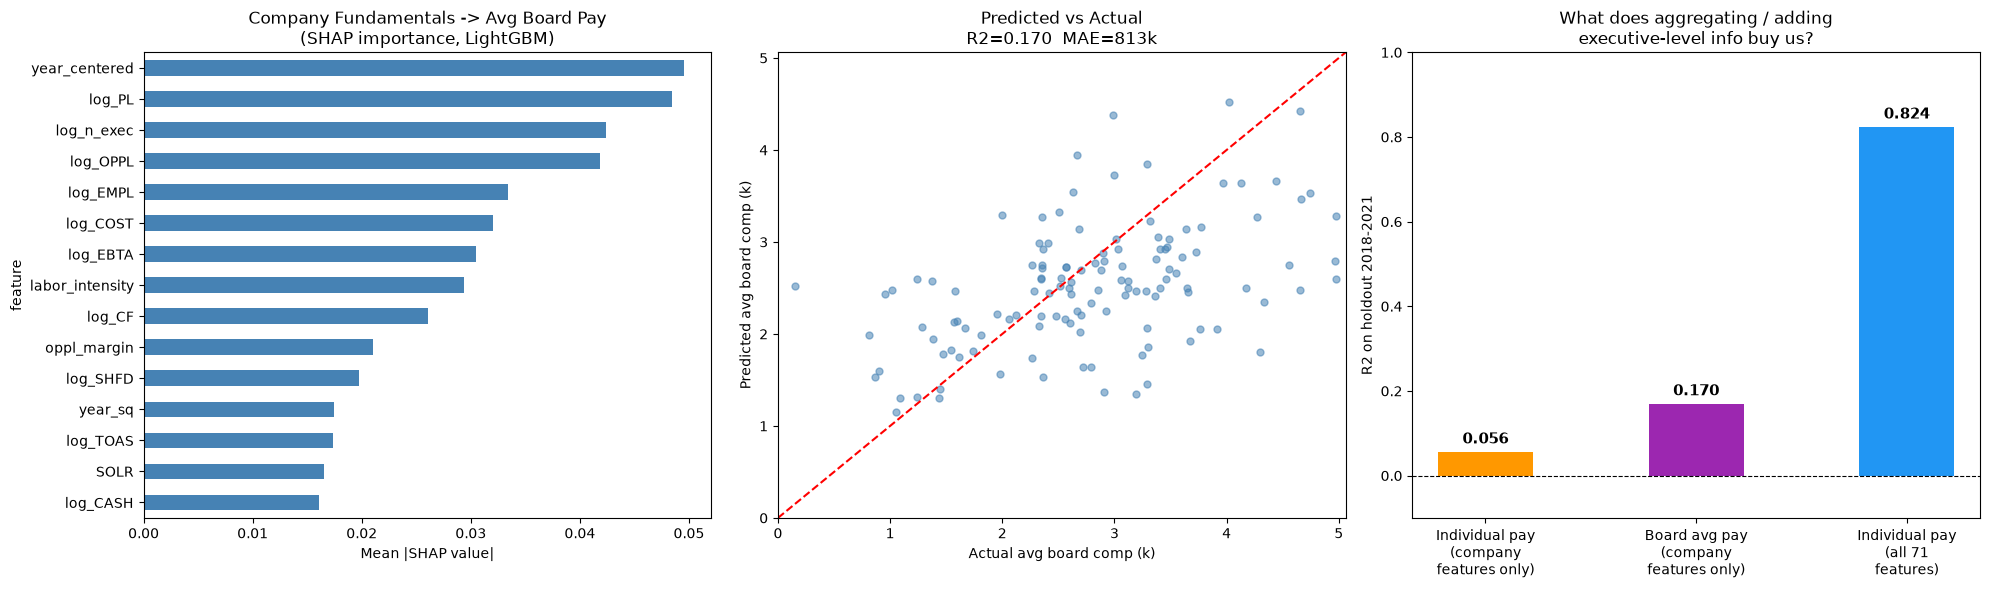

Lasso selected 17/46 features for board avg pay:
log_TURN         0.127
PRMA             0.096
log_n_exec      -0.089
year_centered    0.087
log_TOAS         0.044
ROCE             0.043
log_EBTA         0.043
log_EMPL         0.040
depr_rate       -0.036
log_RD           0.027
rd_intensity     0.026
log_LTDB         0.023
ebta_margin     -0.022
TURN_yoy         0.016
log_SHFD         0.013
EMPL_yoy         0.005
year_sq         -0.001

Top 10 by SHAP:
        feature  mean_abs_shap
  year_centered          0.050
         log_PL          0.048
     log_n_exec          0.042
       log_OPPL          0.042
       log_EMPL          0.033
       log_COST          0.032
       log_EBTA          0.030
labor_intensity          0.029
         log_CF          0.026
    oppl_margin          0.021


In [48]:
# ── 16c · SHAP & visualisation ───────────────────────────────────────────────
expl_b = shap.TreeExplainer(lgb_b)
sv_b   = expl_b.shap_values(pd.DataFrame(Xb_te_f, columns=COMPANY_FEATURES))

shap_b_df = (
    pd.DataFrame({'feature': COMPANY_FEATURES,
                  'mean_abs_shap': np.abs(sv_b).mean(axis=0)})
    .sort_values('mean_abs_shap', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# SHAP bar chart
shap_b_df.head(15).sort_values('mean_abs_shap').plot(
    x='feature', y='mean_abs_shap', kind='barh',
    ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Company Fundamentals -> Avg Board Pay\n(SHAP importance, LightGBM)')
axes[0].set_xlabel('Mean |SHAP value|')

# Predicted vs actual (euro scale)
y_act_k = np.expm1(yb_te) / 1000
y_pre_k = np.expm1(pred_lgb_b) / 1000
lim_k   = (0, float(np.percentile(y_act_k, 97)))
axes[1].scatter(y_act_k, y_pre_k, alpha=0.55, s=25, color='steelblue')
axes[1].plot(lim_k, lim_k, 'r--', lw=1.5)
axes[1].set_xlim(lim_k); axes[1].set_ylim(lim_k)
axes[1].set_xlabel('Actual avg board comp (k)')
axes[1].set_ylabel('Predicted avg board comp (k)')
axes[1].set_title(f'Predicted vs Actual\nR2={r2_lgb_b:.3f}  MAE={mae_lgb_b:.0f}k')

# R2 comparison: individual vs board aggregate, company-only vs full model
r2_full = max(r["R\u00b2"] for r in results)
comp_labels = [
    'Individual pay\n(company\nfeatures only)',
    'Board avg pay\n(company\nfeatures only)',
    'Individual pay\n(all 71\nfeatures)',
]
comp_r2 = [r2_lc, r2_lgb_b, r2_full]
bar_c   = ['#FF9800', '#9C27B0', '#2196F3']
bars = axes[2].bar(comp_labels, comp_r2, color=bar_c, width=0.45)
axes[2].set_ylim(-0.1, 1.0)
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_ylabel('R2 on holdout 2018-2021')
axes[2].set_title('What does aggregating / adding\nexecutive-level info buy us?')
for b, v in zip(bars, comp_r2):
    ypos = v + 0.02 if v >= 0 else v - 0.07
    axes[2].text(b.get_x() + b.get_width()/2, ypos, f'{v:.3f}',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Linear (Lasso) interpretation
lasso_coef_b = pd.Series(lasso_b.coef_, index=COMPANY_FEATURES)
nonzero_b    = lasso_coef_b[lasso_coef_b != 0].sort_values(key=abs, ascending=False)
print(f'Lasso selected {len(nonzero_b)}/{len(COMPANY_FEATURES)} features for board avg pay:')
print(nonzero_b.round(4).to_string())
print('\nTop 10 by SHAP:')
print(shap_b_df.head(10).to_string(index=False))
